In [1]:
import sys, os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


class HazardRatioCohortPipeline:
    """
    Organizes the existing script into an OOP pipeline.
    - You create one object per cohort (e.g., ROSMAP-AD).
    - It executes the same code blocks in the same order.
    - No algorithmic changes; only organization + parameterization by cohort_dir.
    """

    def __init__(self, cohort_dir: str):
        self.cohort_dir = cohort_dir

        # --- robust project root detection ---
        self.CWD = Path.cwd()
        self.PROJECT_ROOT = next(
            (p for p in [self.CWD] + list(self.CWD.parents) if (p / "preprocessing").exists()),
            None
        )
        if self.PROJECT_ROOT is None:
            raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

        # Make imports work + ensure relative paths are consistent
        sys.path.insert(0, str(self.PROJECT_ROOT))
        os.chdir(self.PROJECT_ROOT)

        print("CWD:", self.CWD)
        print("PROJECT_ROOT:", self.PROJECT_ROOT)

        # Will be filled in configure()
        self.DATA_DIR = None
        self.paths = None

        self.metabolite_levels_file_path = None
        self.prs_combined = None
        self.pathway_file_path = None
        self.reaction_file_path = None
        self.metabolite_level_pathway_combined_file_path = None
        self.metabolite_level_reaction_combined_file_path = None
        self.x_pathway_path = None
        self.x_reaction_path = None
        self.best_prs_path = None
        self.clinical_ages_path = None

        self.main_folder = None
        self.hazard_ratio_list = {}

    def configure(self):
        from analysis.config import make_default_paths

        # dataset root
        self.DATA_DIR = self.PROJECT_ROOT / self.cohort_dir
        self.paths = make_default_paths(self.DATA_DIR)

        print("PROJECT_ROOT:", self.PROJECT_ROOT)
        print("DATA_DIR:", self.DATA_DIR)

        self.metabolite_levels_file_path = self.paths.metabolite_levels_file_path
        self.prs_combined = self.paths.prs_combined_path
        self.pathway_file_path = self.paths.pathway_file_path
        self.reaction_file_path = self.paths.reaction_file_path
        self.metabolite_level_pathway_combined_file_path = self.paths.metabolite_level_pathway_combined_file_path
        self.metabolite_level_reaction_combined_file_path = self.paths.metabolite_level_reaction_combined_file_path
        self.x_pathway_path = self.paths.x_pathway_path
        self.x_reaction_path = self.paths.x_reaction_path
        self.best_prs_path = self.paths.best_prs_path
        self.clinical_ages_path = self.paths.clinical_ages_path

        os.makedirs(f"{self.PROJECT_ROOT}/{cohort}/processed", exist_ok=True)
        os.makedirs(f"{self.PROJECT_ROOT}/{cohort}/interim", exist_ok=True)

        # Path to the main folder
        self.main_folder = str(Path(self.cohort_dir) / "Final_Prs_Scores")

    def run(self):
        """
        Executes the full pipeline:
        1) compute hazard ratios
        2) forest plots
        3) write hazard_ratios.csv
        4) summary plots + donut chart
        """
        self.compute_hazard_ratios()
        self.plot_forest_plots()
        output_file = self.write_hazard_ratios_csv()

    def compute_hazard_ratios(self):
        import pandas as pd

        from analysis.cox_regression import compute_hazard_ratios

        from analysis.metabolite_level_analysis import (
            analyse_with_logistic_regression,
            calculate_odds_ratio,
            calculate_hazard_ratio,
            prepare_duration,
            create_ages_df,
            create_ages_df_with_df
        )

        from preprocessing import (
            MetaboliteLevelsPreprocessorFactory,
            PathwayPreprocessorFactory,
            ReactionPreprocessorFactory,
            MetabolitePathwayCombinedPreprocessorFactory,
            MetaboliteReactionCombinedPreprocessorFactory,
            TranscriptomicsPreprocessorFactory,
            TranscriptomicsMetabolitePreprocessorFactory,
            TranscriptomicsPathwayPreprocessorFactory,
            TranscriptomicsReactionPreprocessorFactory
        )

        from sklearn.preprocessing import StandardScaler

        from analysis import calculate_risk_score_with_prs

        factory_list = [
            MetaboliteLevelsPreprocessorFactory(self.metabolite_levels_file_path),
            PathwayPreprocessorFactory(self.metabolite_levels_file_path, self.pathway_file_path, self.x_pathway_path),
            ReactionPreprocessorFactory(self.metabolite_levels_file_path, self.reaction_file_path, self.x_reaction_path),
            MetabolitePathwayCombinedPreprocessorFactory(self.metabolite_levels_file_path, self.metabolite_level_pathway_combined_file_path, self.x_pathway_path),
            MetaboliteReactionCombinedPreprocessorFactory(self.metabolite_levels_file_path, self.metabolite_level_reaction_combined_file_path, self.x_reaction_path),
        ]

        # Loop through each subfolder
        for subfolder in os.listdir(self.main_folder):
            if subfolder in [".ipynb"]:
                continue
            subfolder_path = os.path.join(self.main_folder, subfolder)
            hazard_ratios = {}
            # Check if it's a directory
            if os.path.isdir(subfolder_path):
                prs_id = subfolder
                csv_path = os.path.join(subfolder_path, 'prs_scores.csv')
                prs_scores = pd.read_csv(csv_path)  # Contains individual IDs and scores
                rosmap_clinical = pd.read_csv(str(Path(self.cohort_dir) / 'raw' / 'clinical.csv'))  # Contains ID, Study, and projid

                # Merge on individual ID
                rosmap_clinical['sample_id'] = rosmap_clinical['Sample ID'].astype(str)
                prs_scores['sample_id'] = prs_scores['sample_id'].astype(str)
                merged = prs_scores.merge(rosmap_clinical, on='sample_id', how='inner')
                prs_df = merged[['sample_id', 'score']]

                for factory in factory_list:
                    preprocessor = factory.create_preprocessor()
                    y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
                    ages_df = create_ages_df(preprocessor.file_path, self.clinical_ages_path)
                    
                    duration_df = prepare_duration(ages_df)
                    
                    hr = compute_hazard_ratios(risk_scores, duration_df)
                    
                    hazard_ratios[preprocessor.name] = hr

                    combined_risk_df = calculate_risk_score_with_prs(y, risk_scores, sample_ids_, prs_df, self.prs_combined)
                    ages_prs = create_ages_df_with_df(combined_risk_df['sample_id_biomarker'], self.clinical_ages_path, self.metabolite_levels_file_path)
                    duration_prs = prepare_duration(ages_prs)
                    hr_with_prs = compute_hazard_ratios(combined_risk_df['combined_score'], duration_prs)

                    hazard_ratios[preprocessor.name + " PRS"] = hr_with_prs

                scaler = StandardScaler()
                prs_df.loc[:, "score"] = scaler.fit_transform(prs_df[["score"]])

                ages_prs_ = create_ages_df_with_df(prs_df["sample_id"], self.clinical_ages_path, self.metabolite_levels_file_path)
                duration_prs_ = prepare_duration(ages_prs_)
                hr_prs = compute_hazard_ratios(prs_df['score'], duration_prs_)
                hazard_ratios["Prs Score "] = hr_prs
                self.hazard_ratio_list[prs_id] = hazard_ratios

    def plot_forest_plots(self):
        import matplotlib.pyplot as plt
        import numpy as np

        for subfolder in os.listdir(self.main_folder):
            if subfolder in ['.DS_Store', '.ipynb']:
                continue
            labels = list(self.hazard_ratio_list[subfolder].keys())
            odds_ratios = np.array(list(self.hazard_ratio_list[subfolder].values()))

            fig, ax = plt.subplots(figsize=(10, 6))
            fig.patch.set_facecolor('white')  # Set figure background to white
            ax.set_facecolor('white')         # Set axes background to white

            y_pos = np.arange(len(labels))
            colors = plt.cm.Set2.colors  # Light, pastel colors

            for i, (odds, label) in enumerate(zip(odds_ratios, labels)):
                color = colors[(i // 2) % len(colors)]  # Use same color for pairs (0-1, 2-3, ...)
                ax.plot(odds, y_pos[i], 'o', color=color, markersize=8)
                ax.text(odds + 0.2, y_pos[i] - 0.15, f"{odds:.2f}",
                        va='bottom', ha='left', fontsize=9, color='black')

            ax.set_yticks(y_pos)
            ax.set_yticklabels(labels, color='black')
            ax.invert_yaxis()
            ax.set_xlabel("Hazard Ratio", color='black')
            ax.set_title("Forest Plot with Prs " + subfolder, color='black')
            ax.set_xlim(0, max(odds_ratios) + 3)

            # Only vertical grid lines
            ax.grid(True, axis='x', linestyle='--', alpha=0.6, color='gray')

            # Optional: remove top/right spines
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.tick_params(colors='black')

            plt.tight_layout()

            output_path = os.path.join("plots", self.cohort_dir, "hazard_ratios", f"forest_plot_{subfolder}.png")
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, facecolor='white')  # Save with white background

            plt.show()

    def write_hazard_ratios_csv(self):
        import csv
        import numpy as np

        output_file = str(Path(self.cohort_dir) / 'processed' / 'hazard_ratios.csv')
        os.makedirs(os.path.dirname(output_file), exist_ok=True)

        # Get all unique labels from the first valid subfolder to use as headers
        for subfolder in os.listdir(self.main_folder):
            if subfolder in ['.DS_Store', '.ipynb']:
                continue
            if subfolder in self.hazard_ratio_list:
                labels = list(self.hazard_ratio_list[subfolder].keys())
                break

        # Open the file and write headers and rows
        with open(output_file, mode='w', newline='') as file:
            writer = csv.writer(file)

            # Write header
            header = ['PRS name'] + labels
            writer.writerow(header)

            # Write each row
            for subfolder in os.listdir(self.main_folder):
                if subfolder not in self.hazard_ratio_list or '.DS_Store' == subfolder:
                    continue
                labels = list(self.hazard_ratio_list[subfolder].keys())
                odds_ratios = np.array(list(self.hazard_ratio_list[subfolder].values()))
                row = [subfolder] + list(odds_ratios)
                writer.writerow(row)

        return output_file

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/MayoRNASeq-PSP
Log(HR) (coef): 0.8823821605757443
Hazard Ratio (exp(coef)): 2.4166497026379443
P-value: 0.013274841520437276
Log(HR) (coef): 0.5554952374798958
Hazard Ratio (exp(coef)): 1.7428038728871333
P-value: 0.1190475276288617
Log(HR) (coef): 0.2927880399954348
Hazard Ratio (exp(coef)): 1.3401587002806405
P-value: 0.41089808100305636
Log(HR) (coef): 0.42225068223889506
Hazard Ratio (exp(coef)): 1.5253908651555617
P-value: 0.23633211840180457
Log(HR) (coef): 0.7165960279744223
Hazard Ratio (exp(coef)): 2.047451866357847
P-value: 0.04837344326842052
Log(HR) (coef): 0.4289307405138038
Hazard Ratio (exp(coef)): 1.5356146748308133
P-value: 0.2291583165744044
Log(HR) (coef): 0.8481462926821032
Hazard Ratio (exp(coef)): 2.335313848735909
P-value:

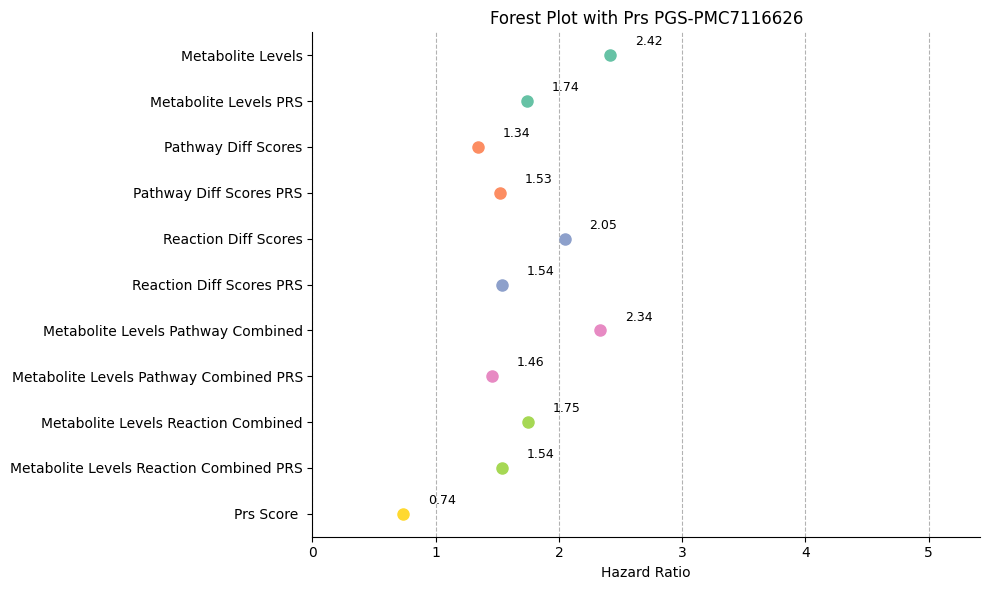

CWD: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/DIABETES
Log(HR) (coef): -0.017143038161469316
Hazard Ratio (exp(coef)): 0.9830030676268382
P-value: 0.9180281171143726
Log(HR) (coef): 0.06586839043167395
Hazard Ratio (exp(coef)): 1.0680861375598862
P-value: 0.5322718776199553
Log(HR) (coef): 0.005194282407434092
Hazard Ratio (exp(coef)): 1.005207796080111
P-value: 0.9750946651754819
Log(HR) (coef): -0.07508826276437165
Hazard Ratio (exp(coef)): 0.9276616047374227
P-value: 0.47894300098446874
Log(HR) (coef): 0.2362502007245744
Hazard Ratio (exp(coef)): 1.2664911475315375
P-value: 0.16550700340766739
Log(HR) (coef): 0.29318144057302115
Hazard Ratio (exp(coef)): 1.3406860232051592
P-value: 0.004739436876707182
Log(HR) (coef): -0.015359197259975
Hazard Ratio (exp(coef)): 0.9847581536368673
P-value: 0.92649

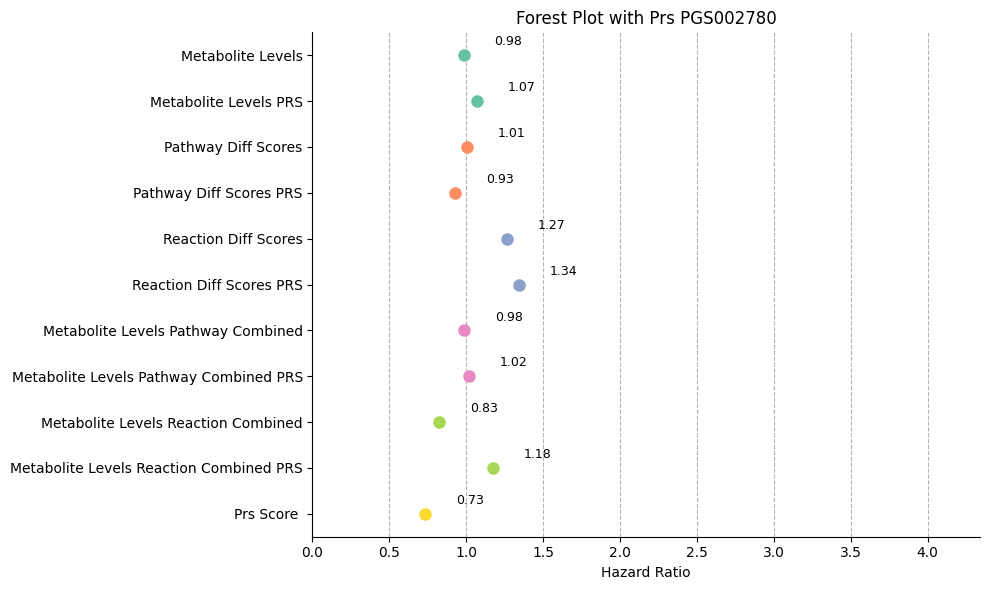

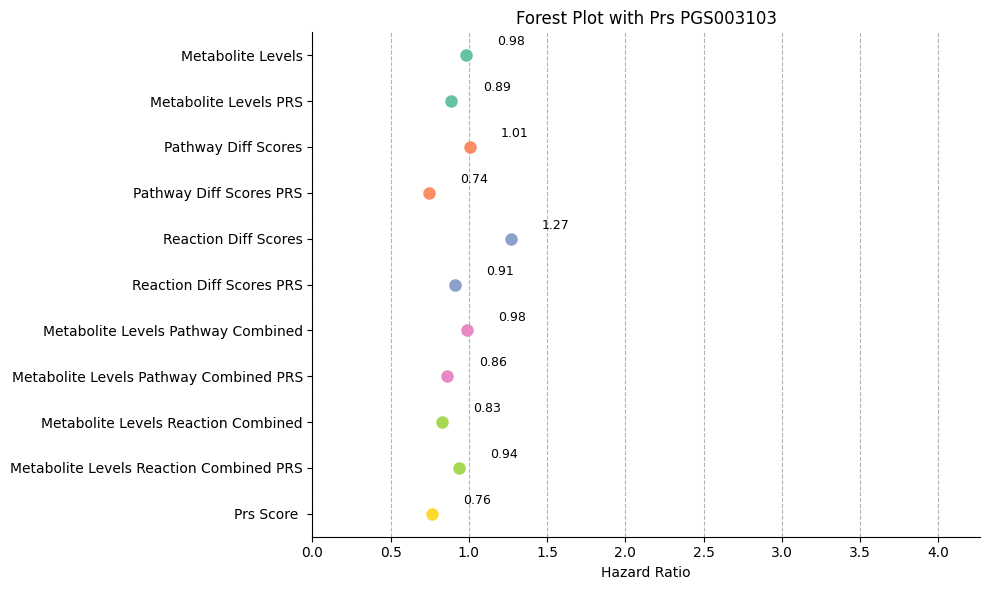

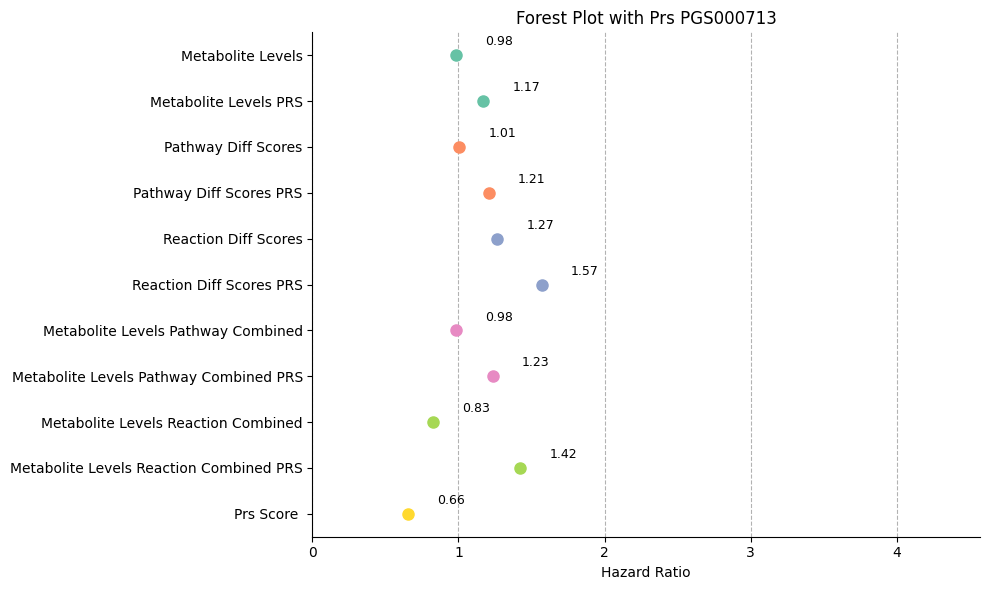

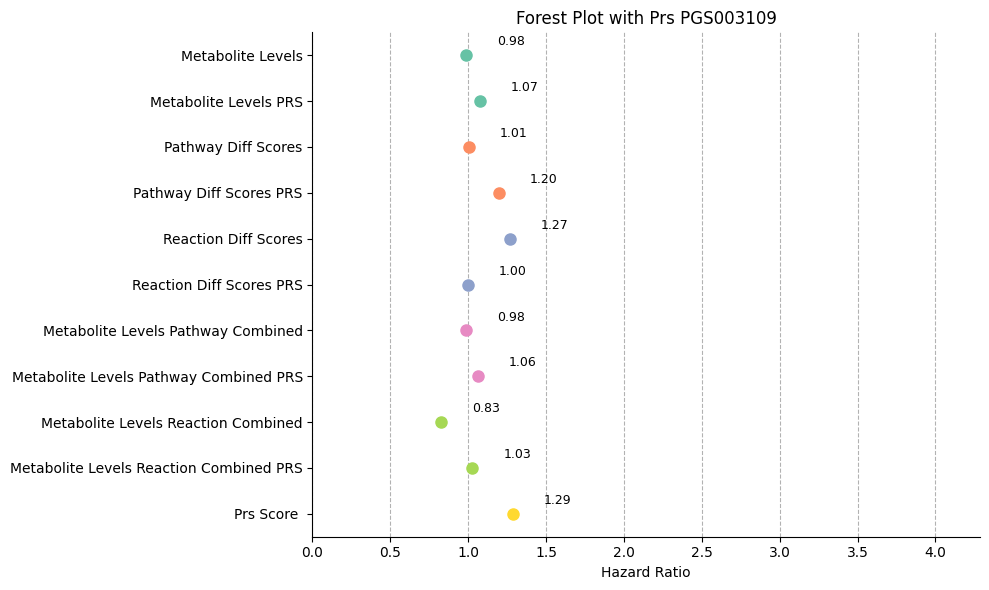

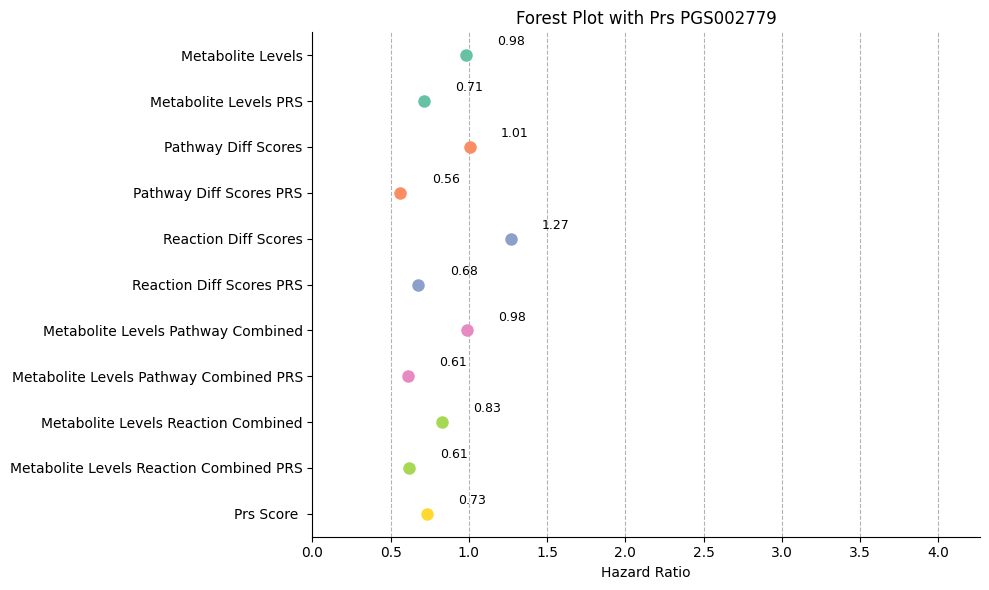

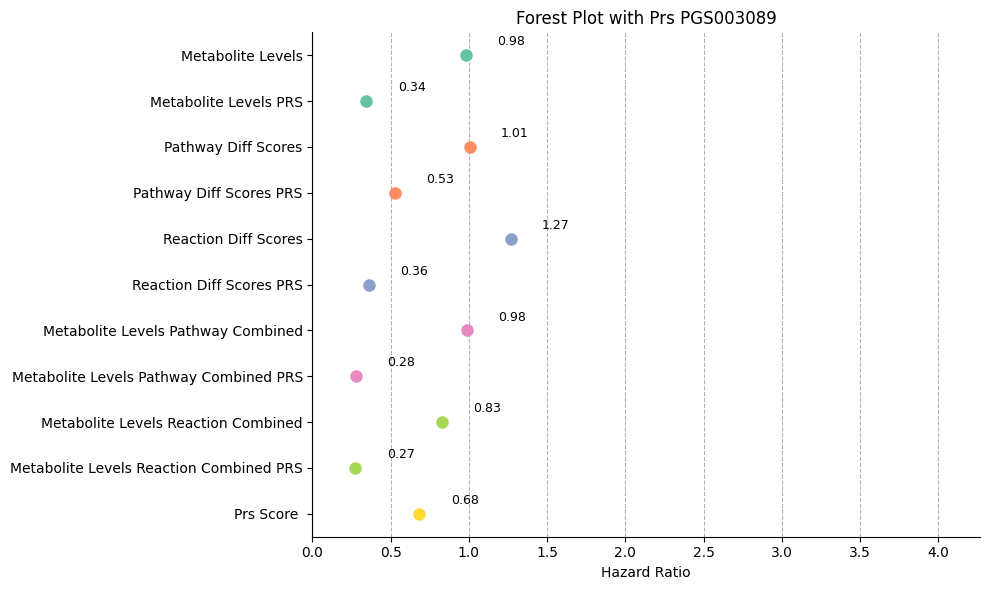

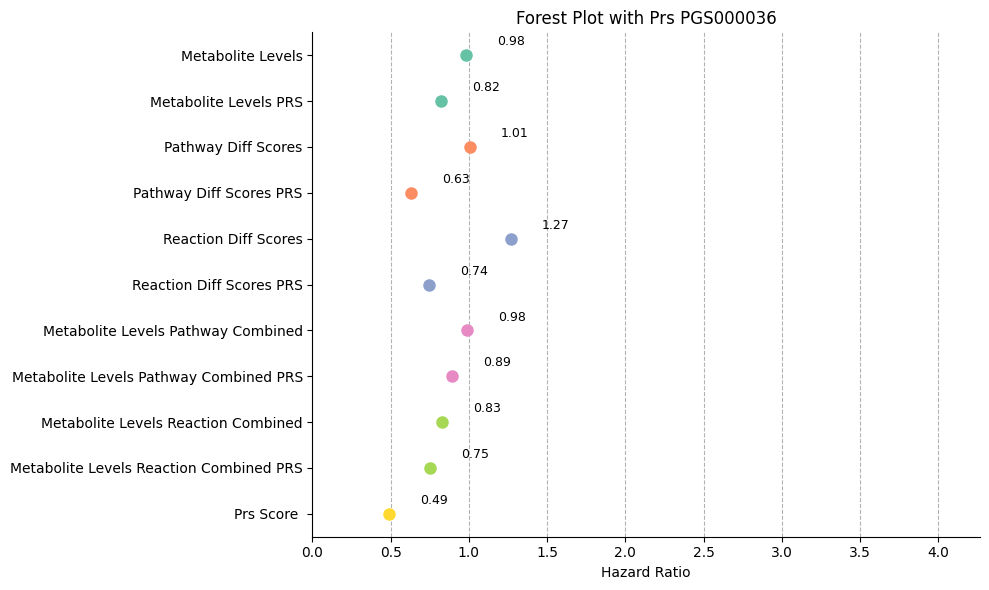

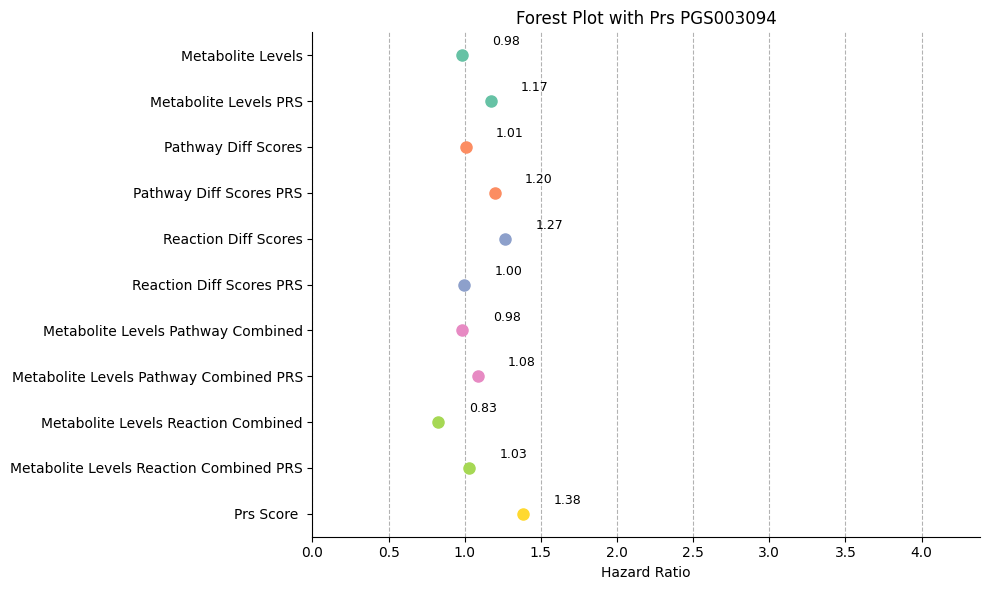

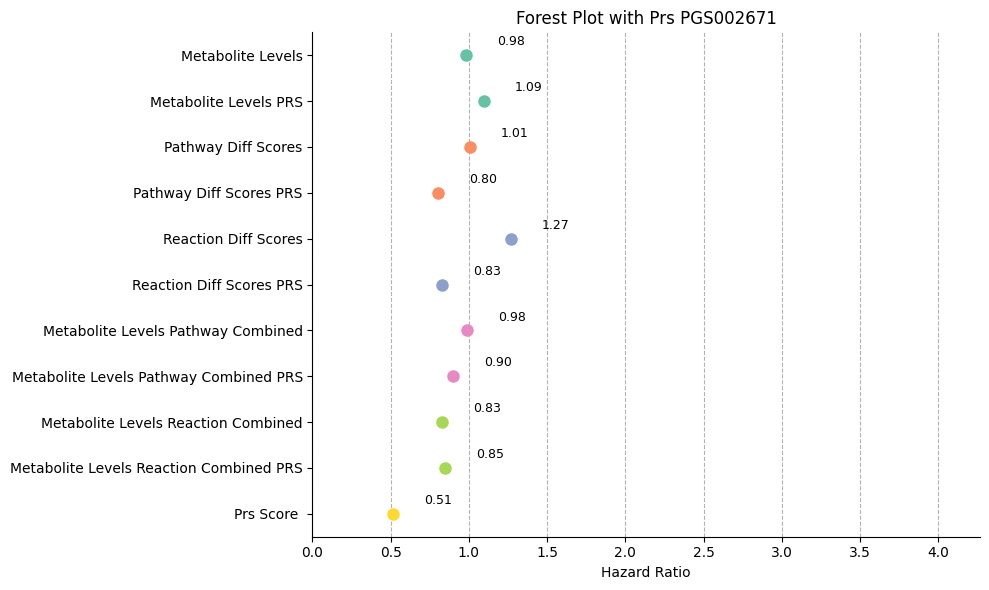

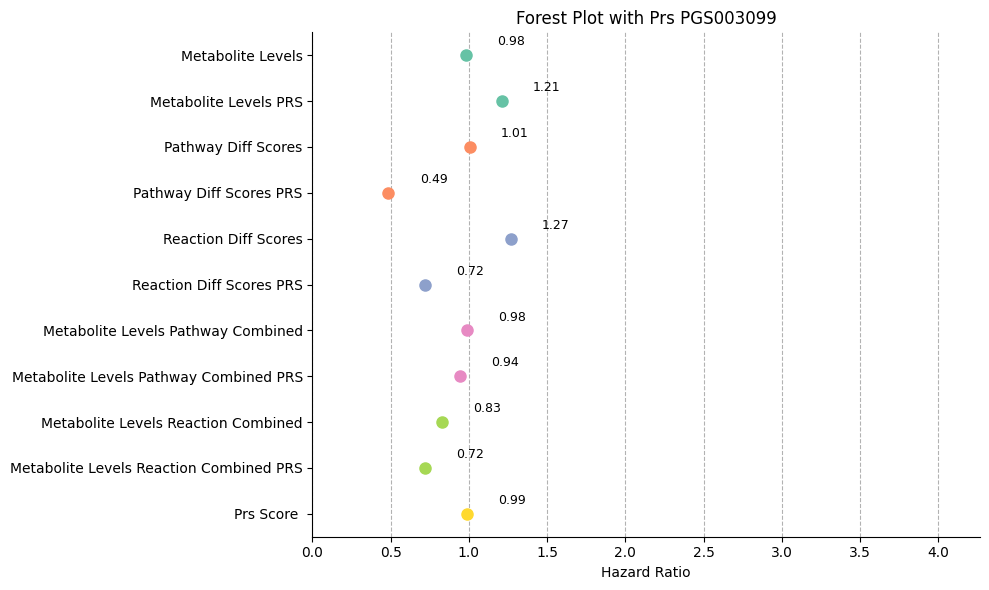

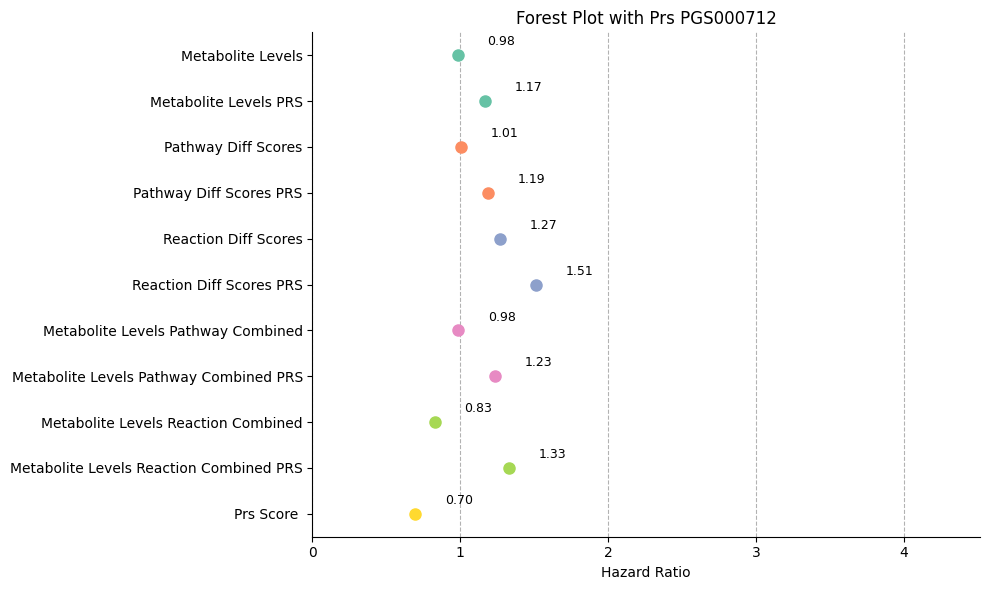

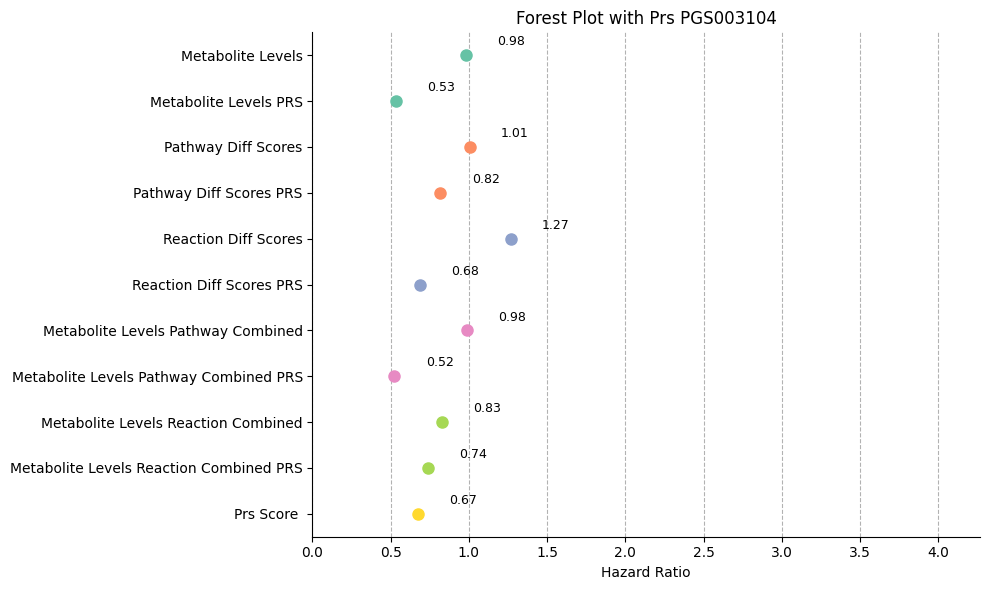

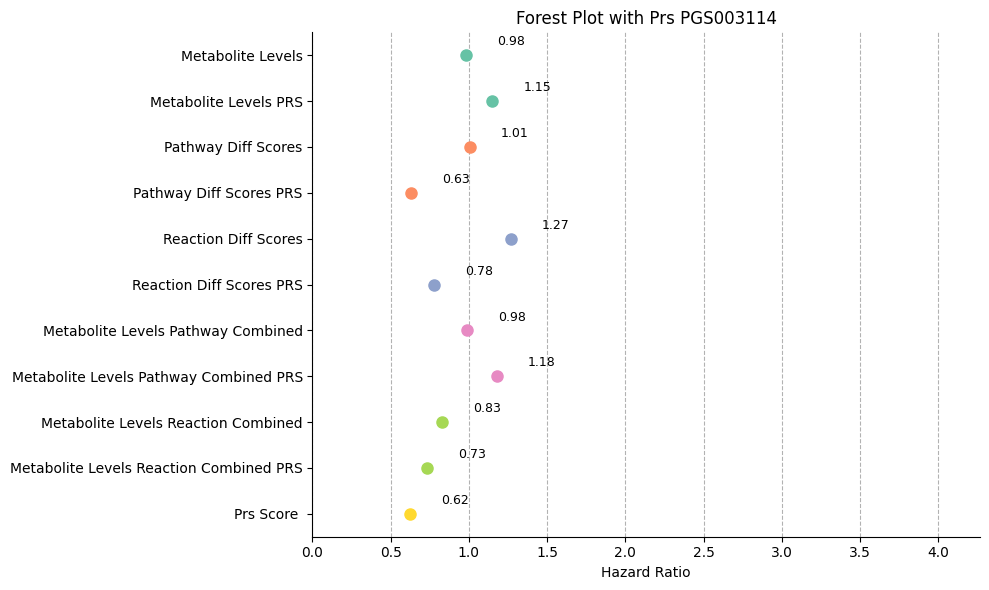

CWD: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/MayoRNASeq-AD
Log(HR) (coef): 0.744769218543131
Hazard Ratio (exp(coef)): 2.1059553634478587
P-value: 0.04969743748094406
Log(HR) (coef): 0.35659144147758426
Hazard Ratio (exp(coef)): 1.4284521443215505
P-value: 0.3468318285211307
Log(HR) (coef): 0.5771239193788315
Hazard Ratio (exp(coef)): 1.780909020065869
P-value: 0.12846773621544505
Log(HR) (coef): 0.3215392400151214
Hazard Ratio (exp(coef)): 1.3792491267208542
P-value: 0.3963909134654844
Log(HR) (coef): 0.6449905847623492
Hazard Ratio (exp(coef)): 1.905969084035562
P-value: 0.1118528831364644
Log(HR) (coef): 0.2785828970550525
Hazard Ratio (exp(coef)): 1.3212561290984015
P-value: 0.4626536489657378
Log(HR) (coef): 1.0898957090123056
Hazard Ratio (exp(coef)): 2.973963898756811
P-value: 0.0044190988641

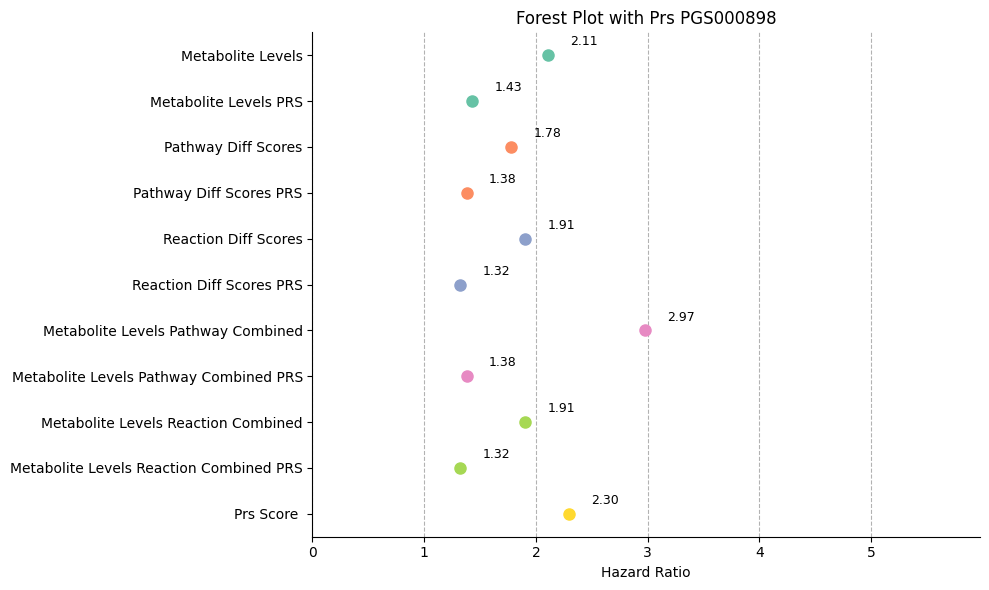

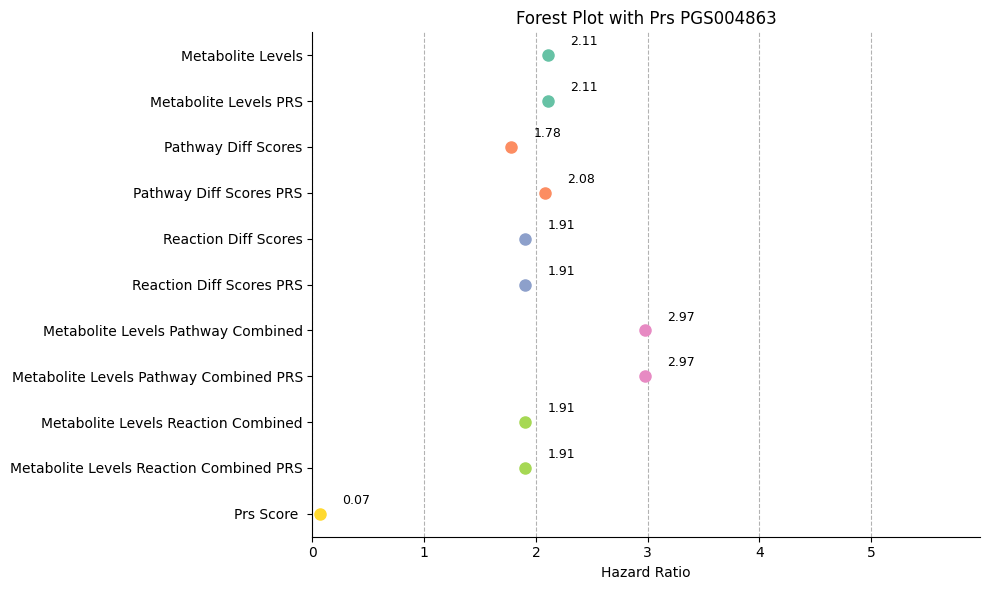

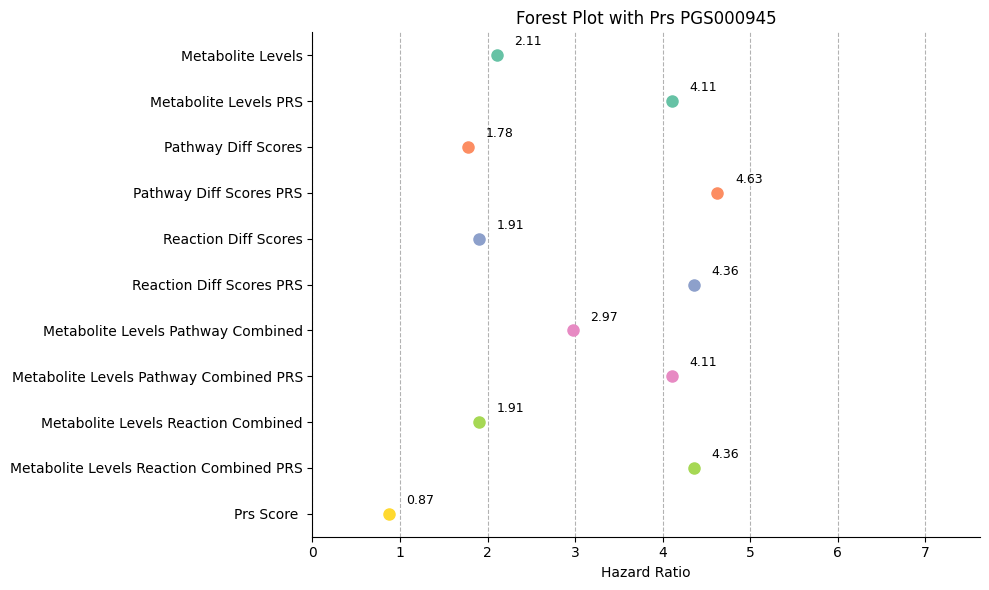

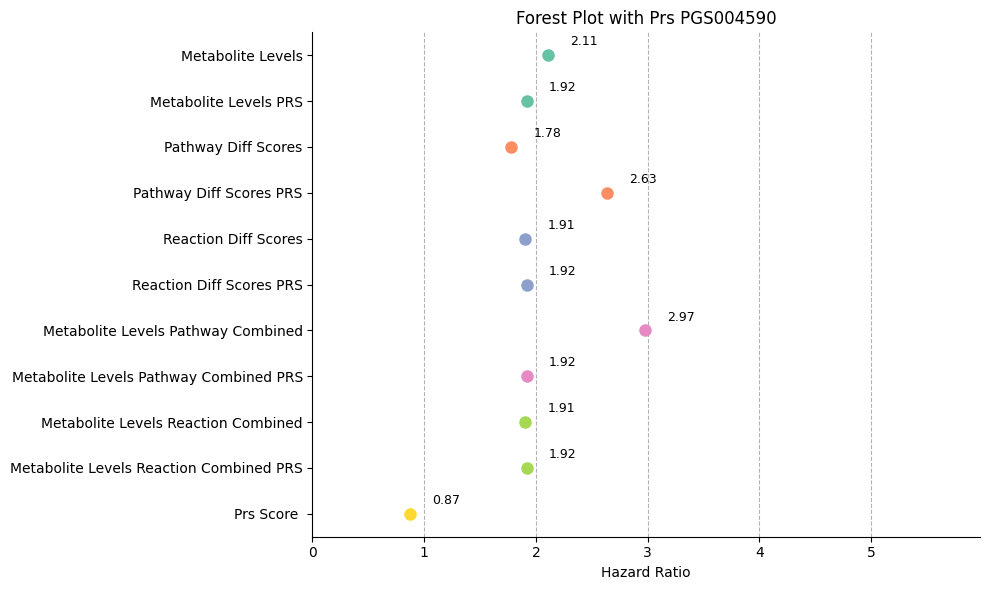

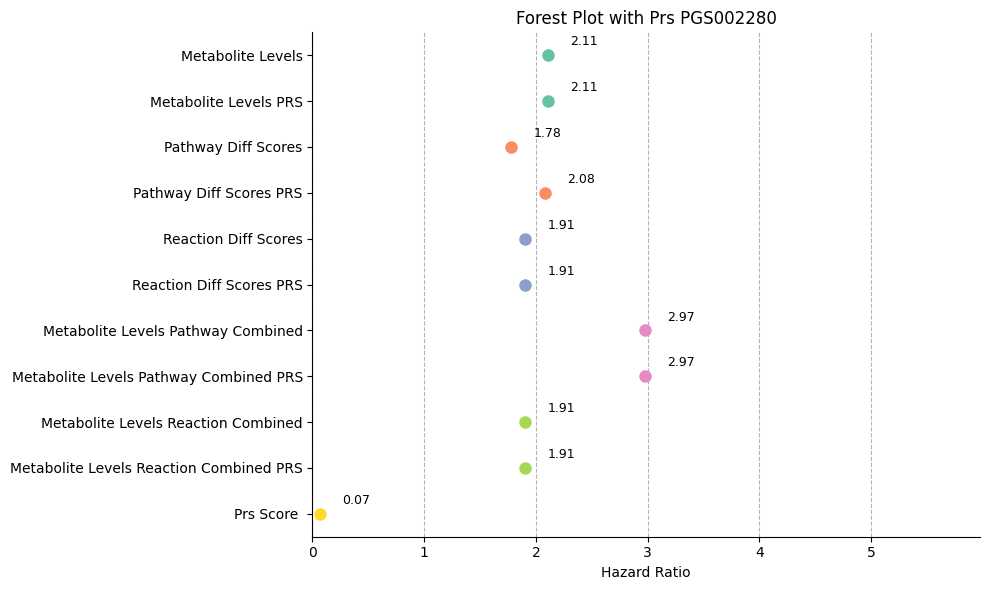

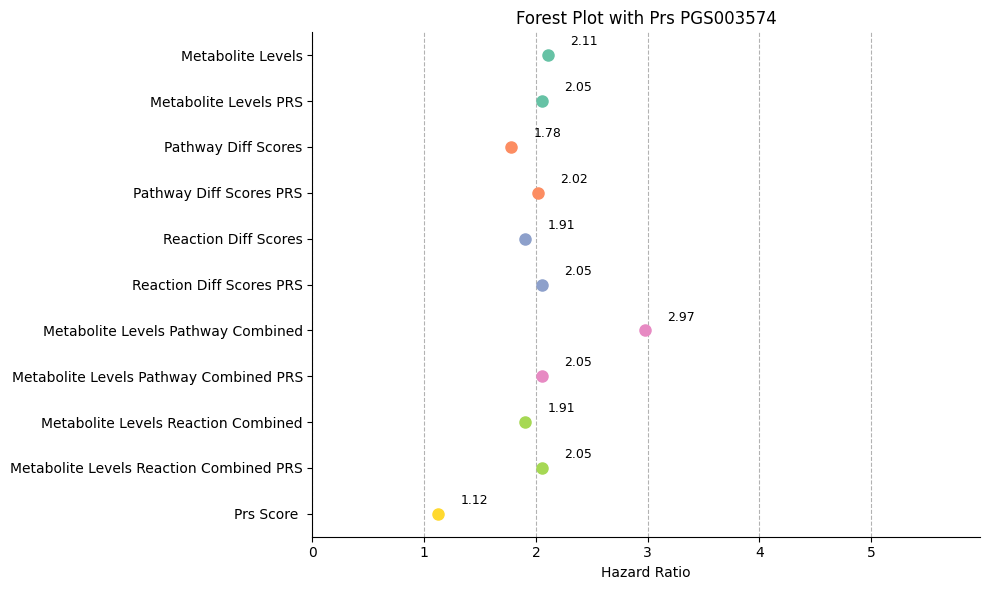

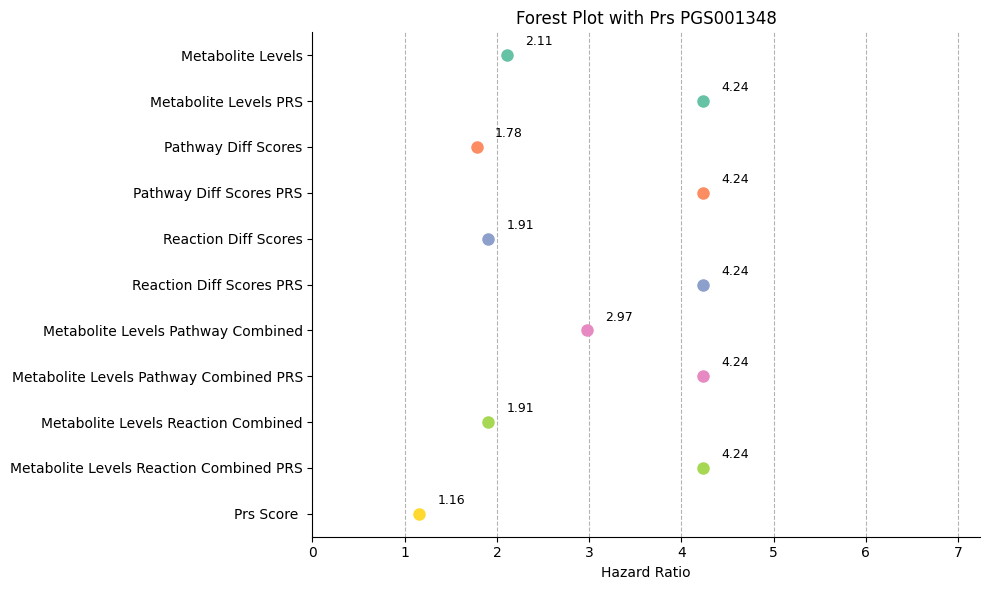

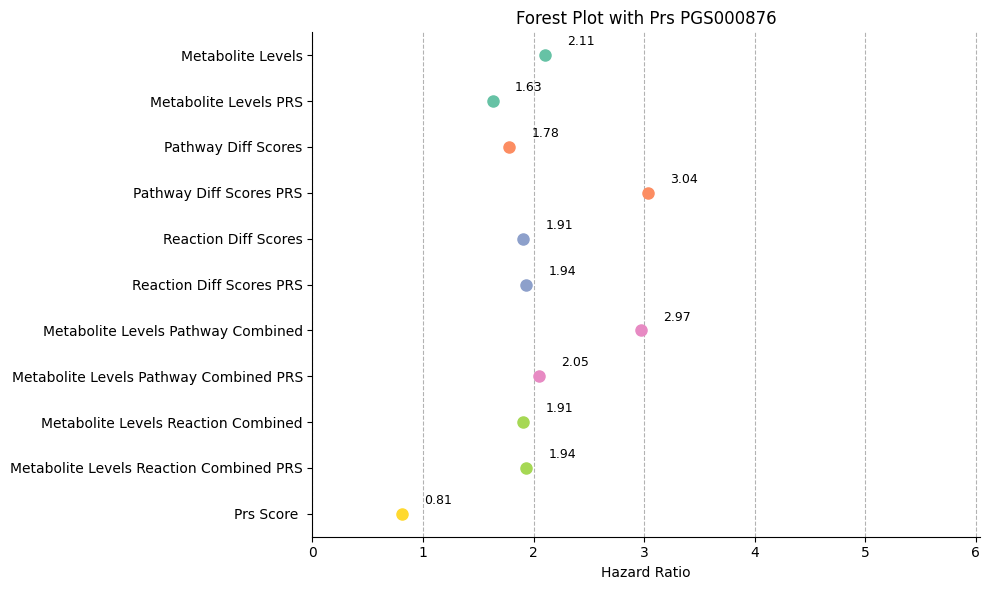

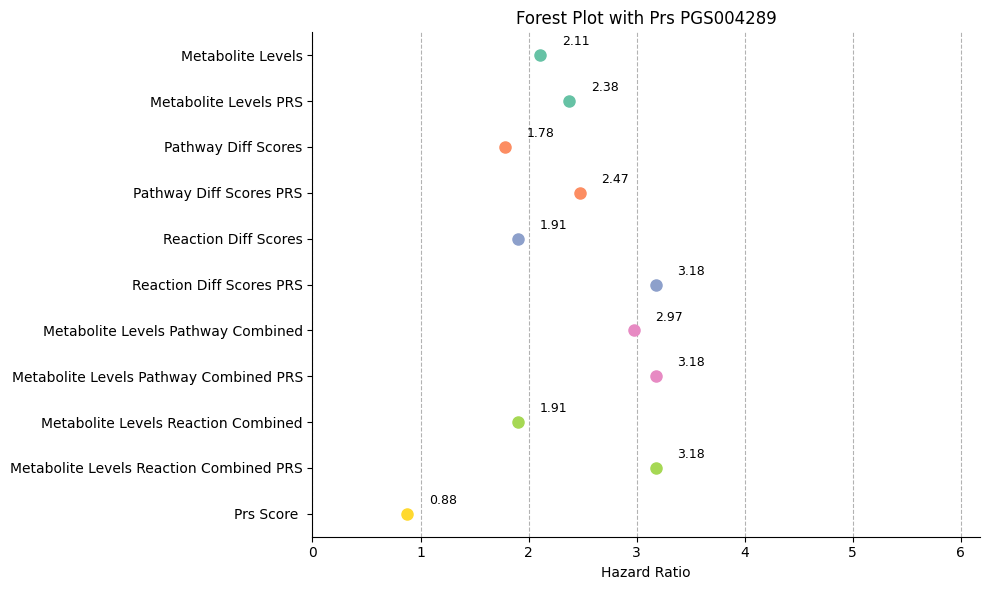

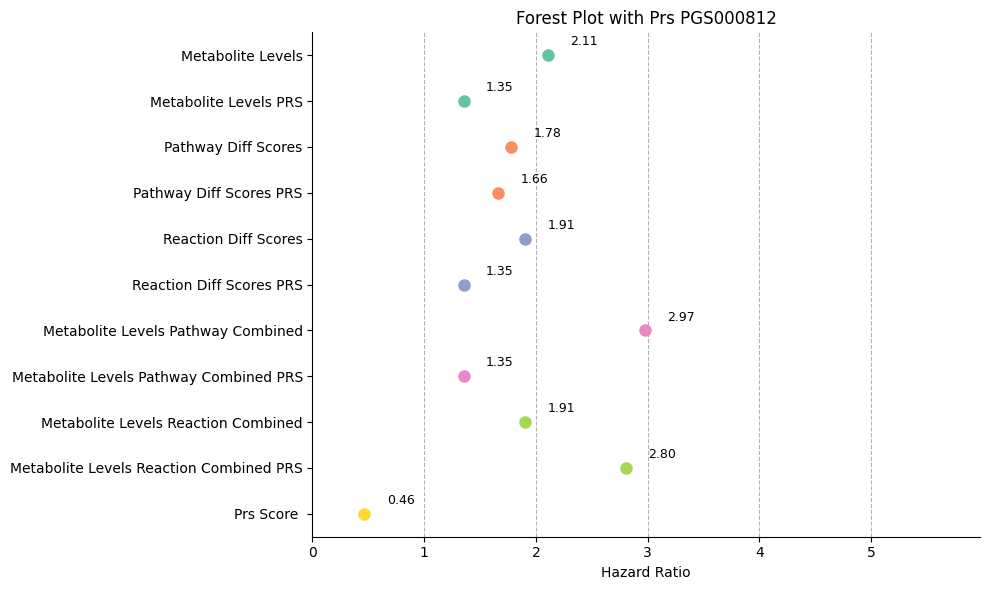

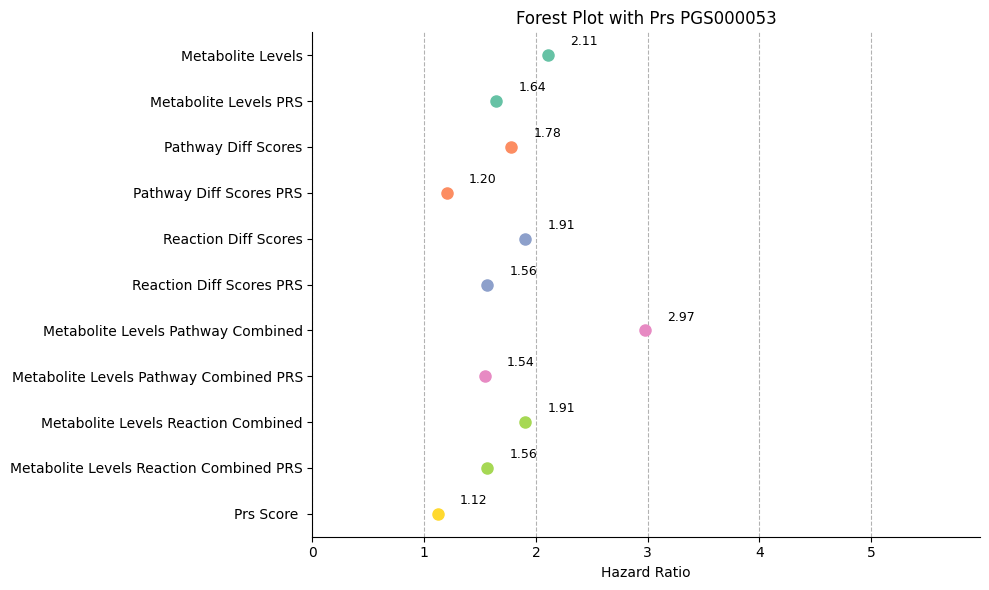

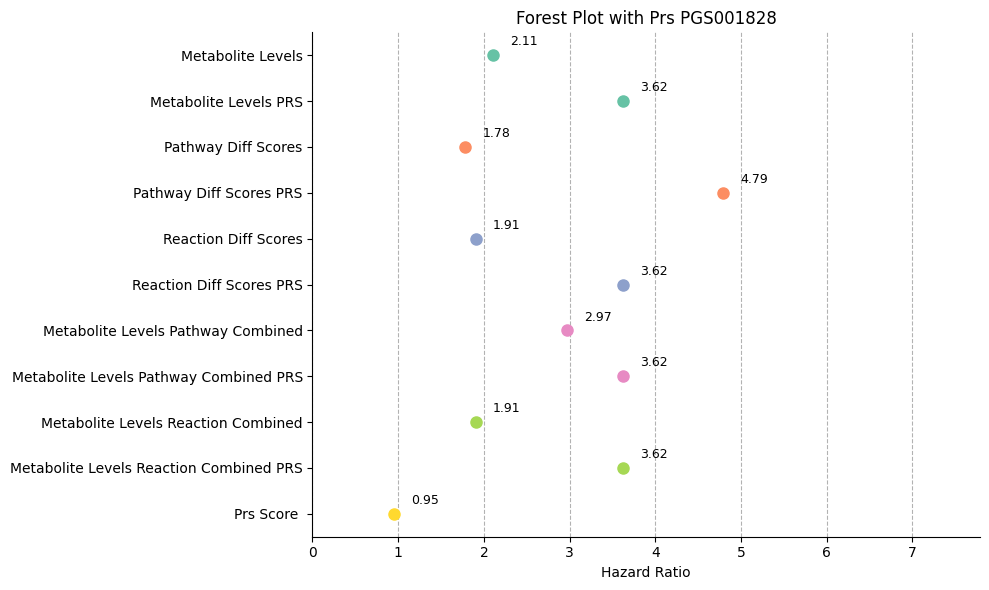

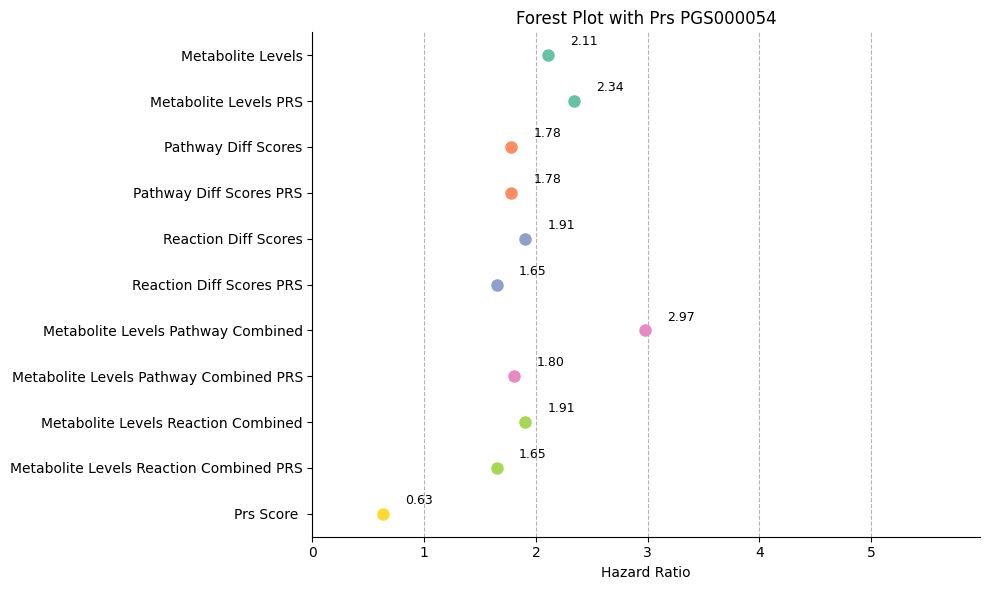

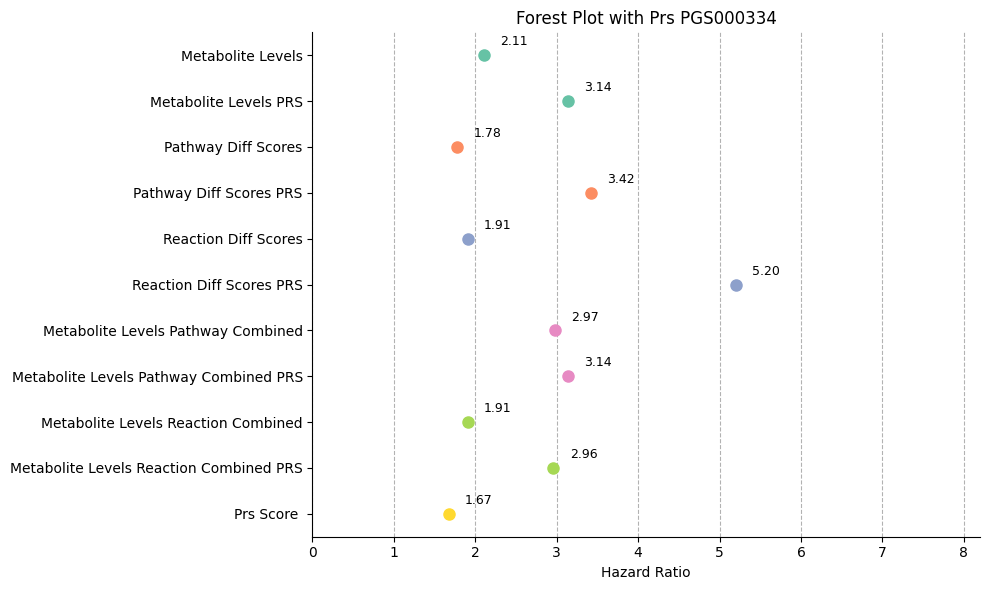

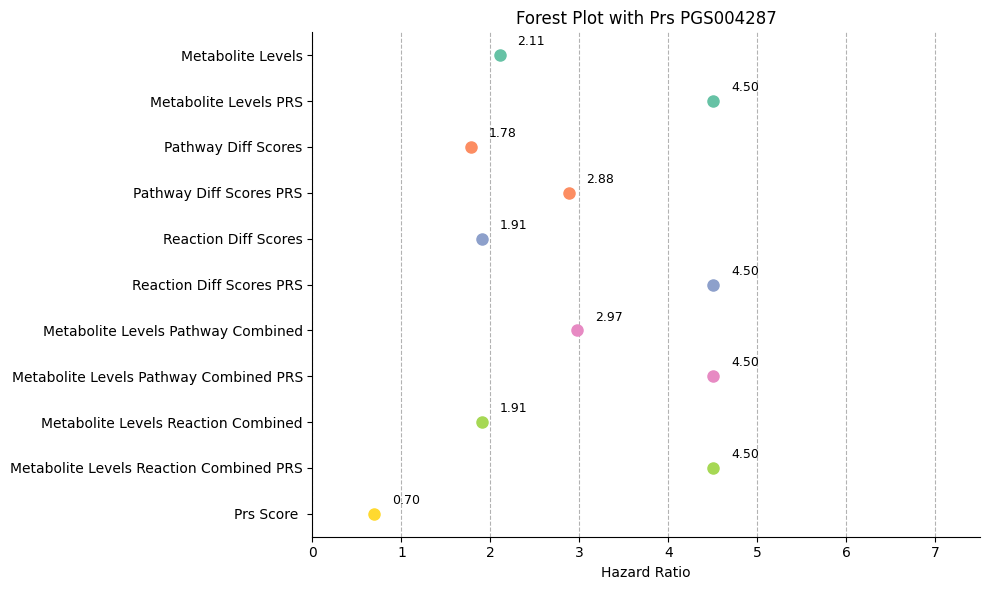

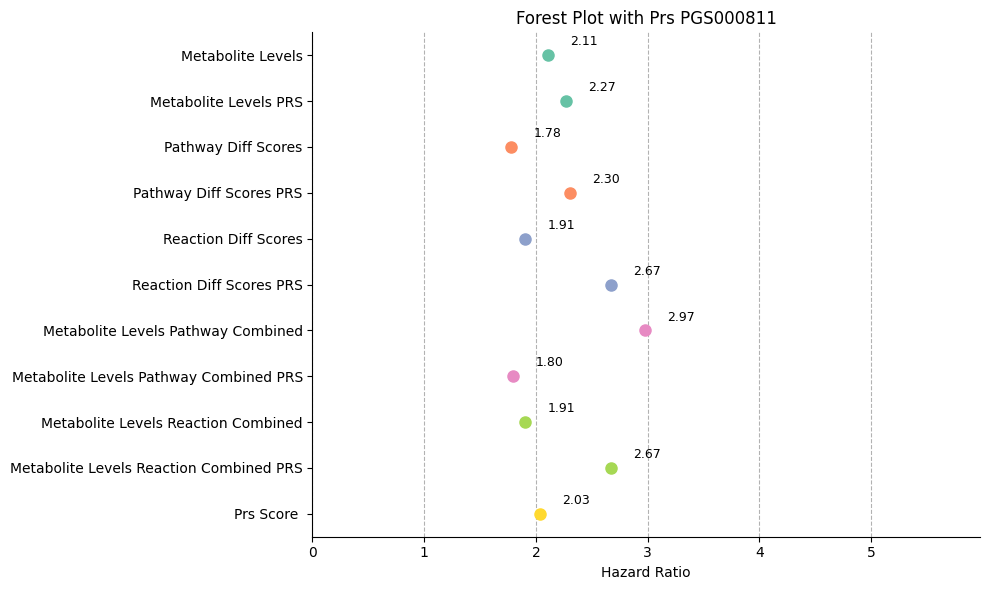

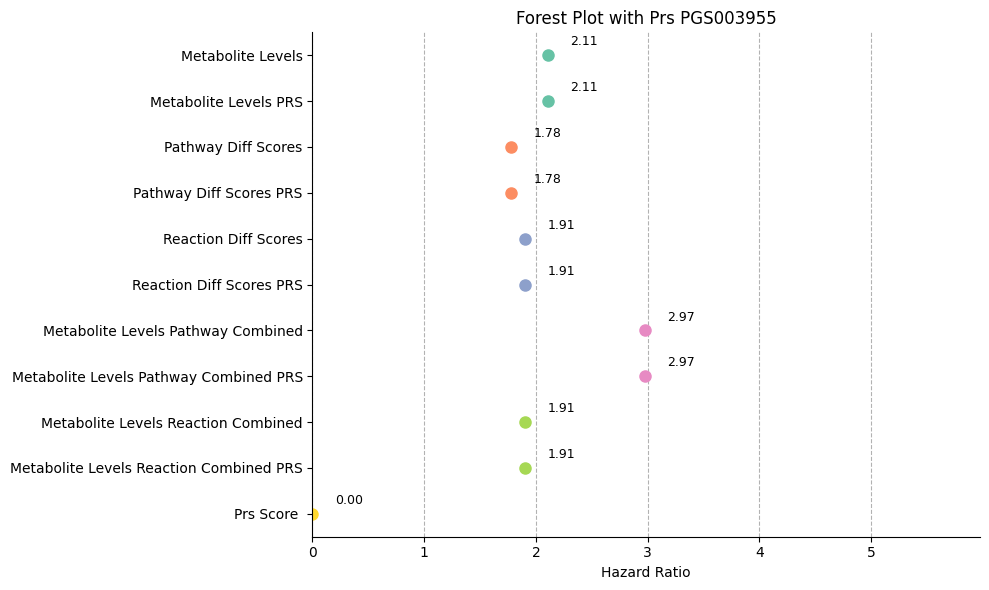

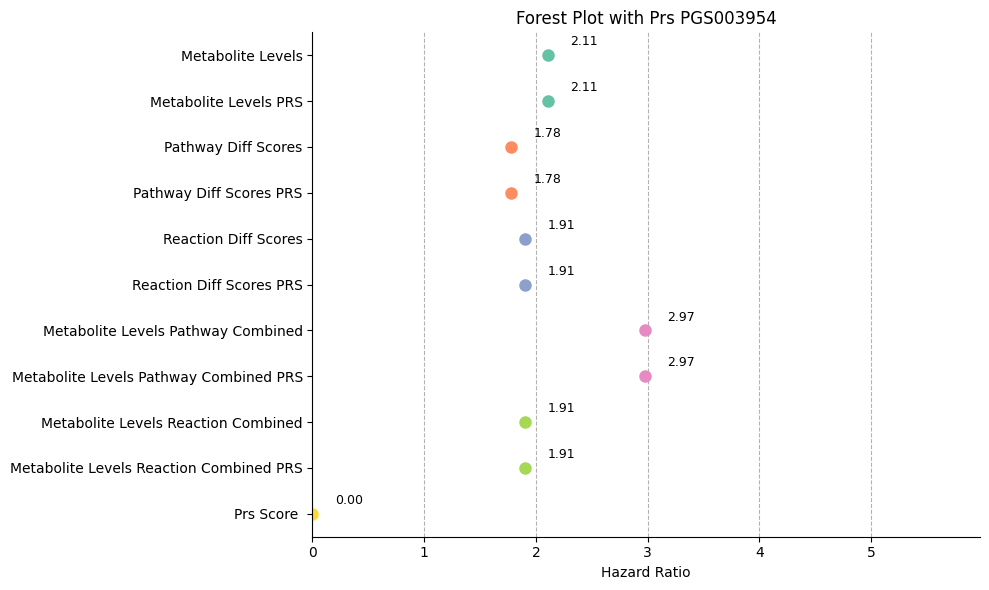

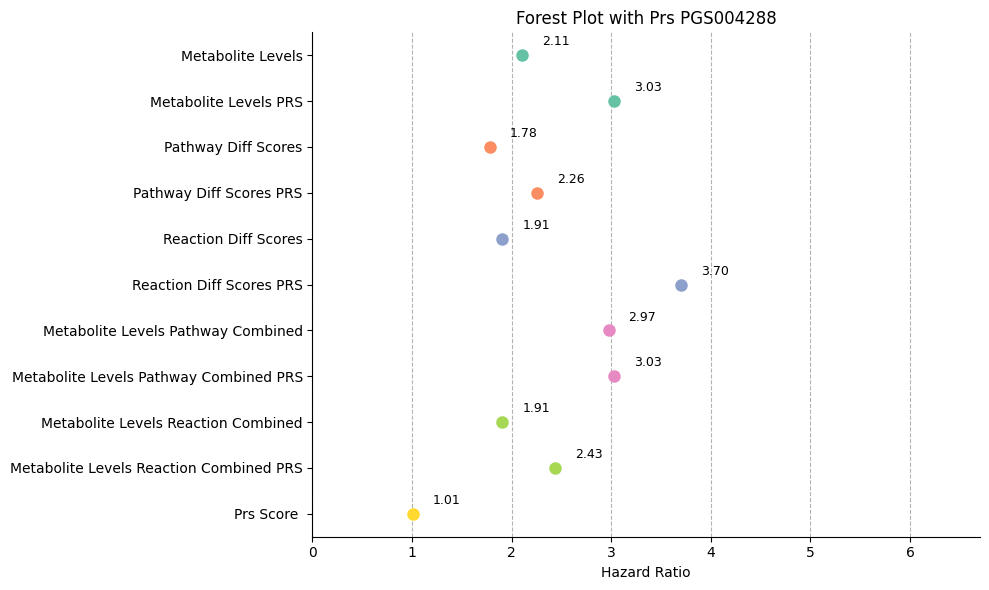

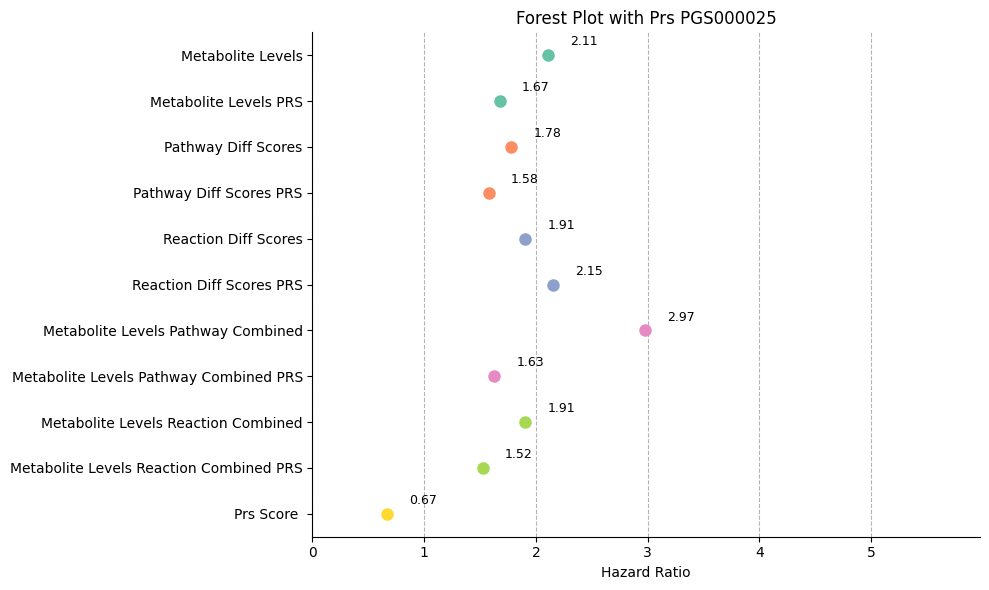

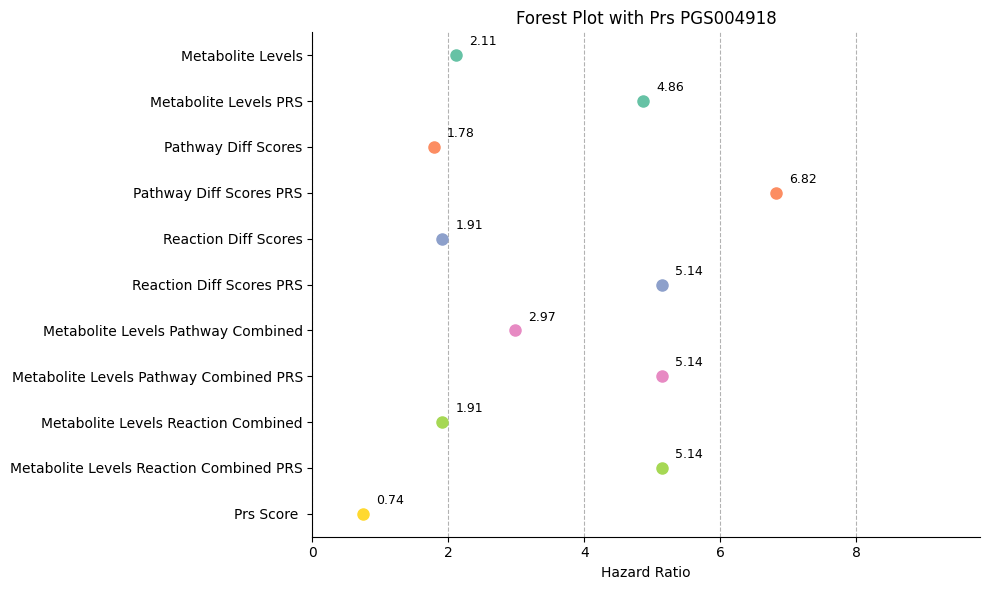

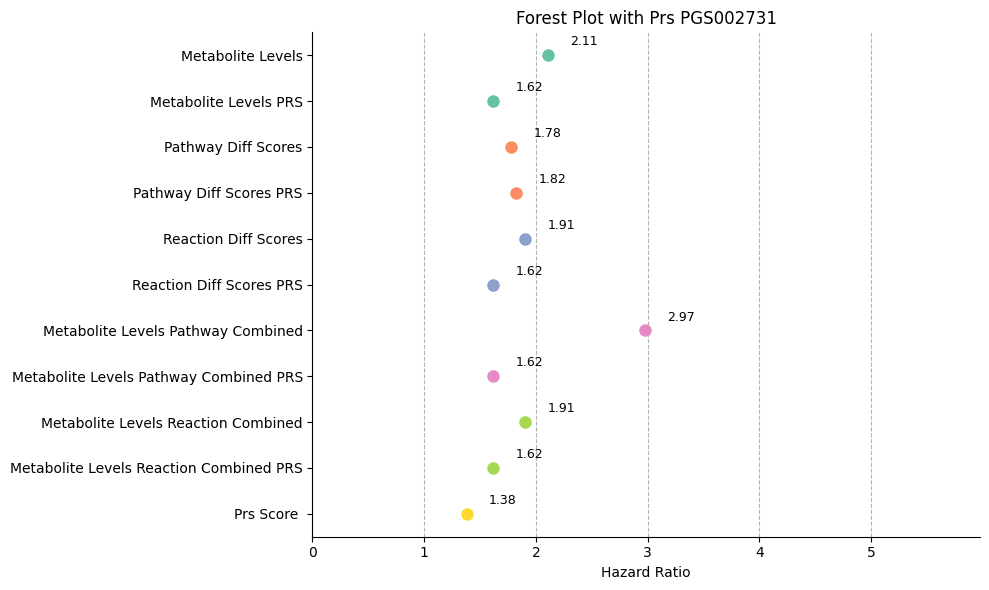

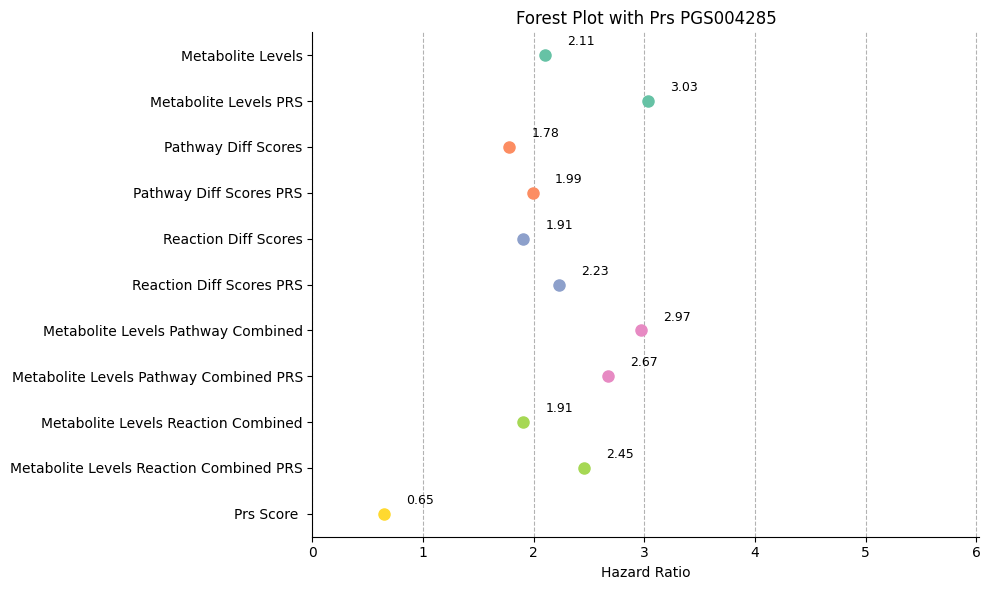

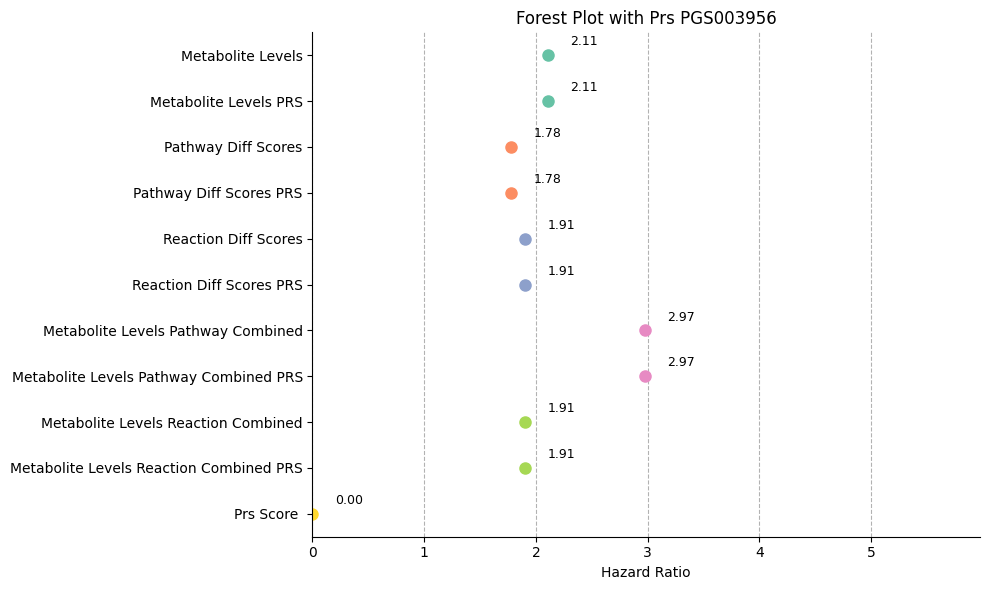

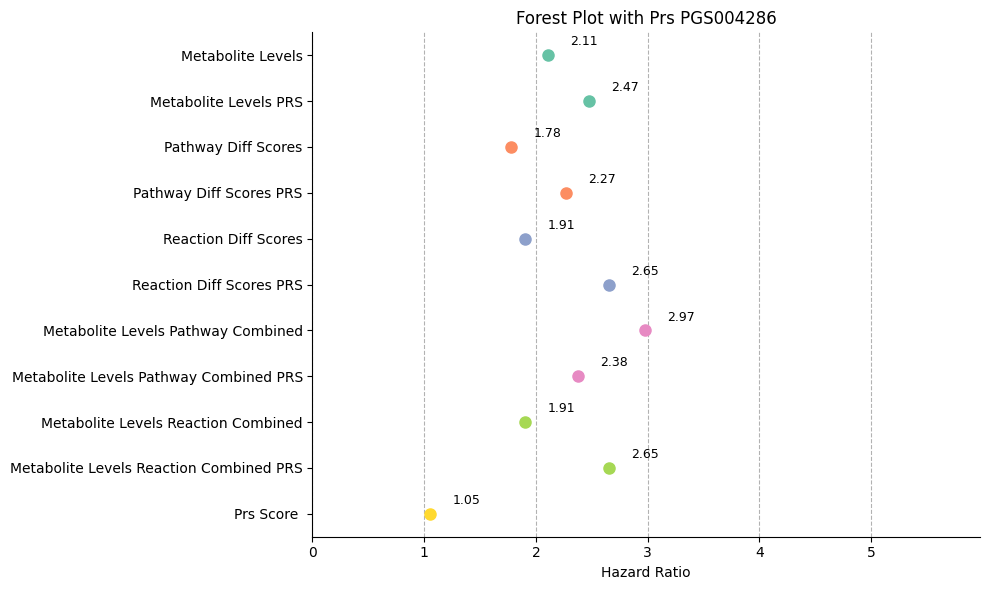

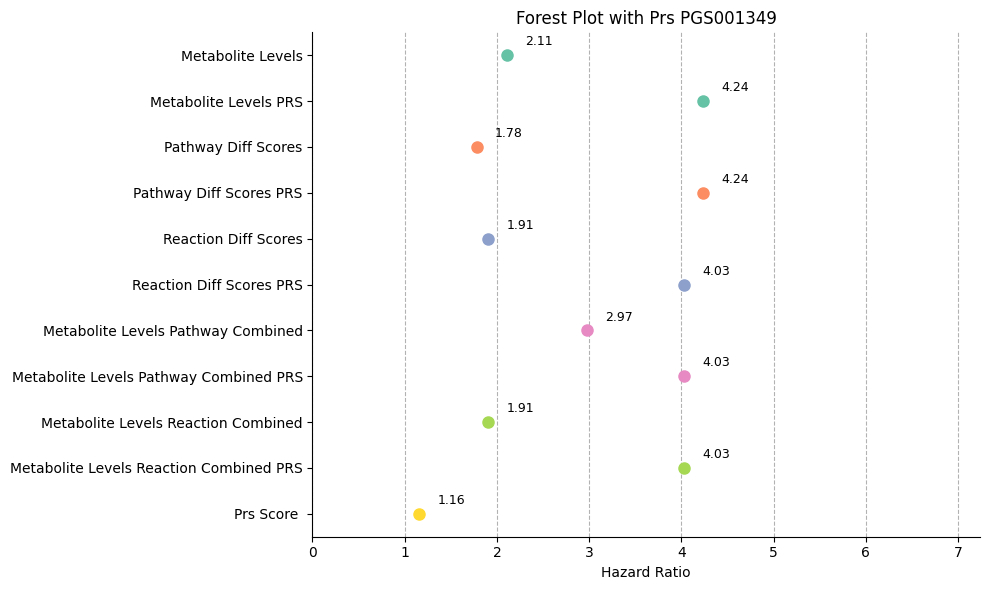

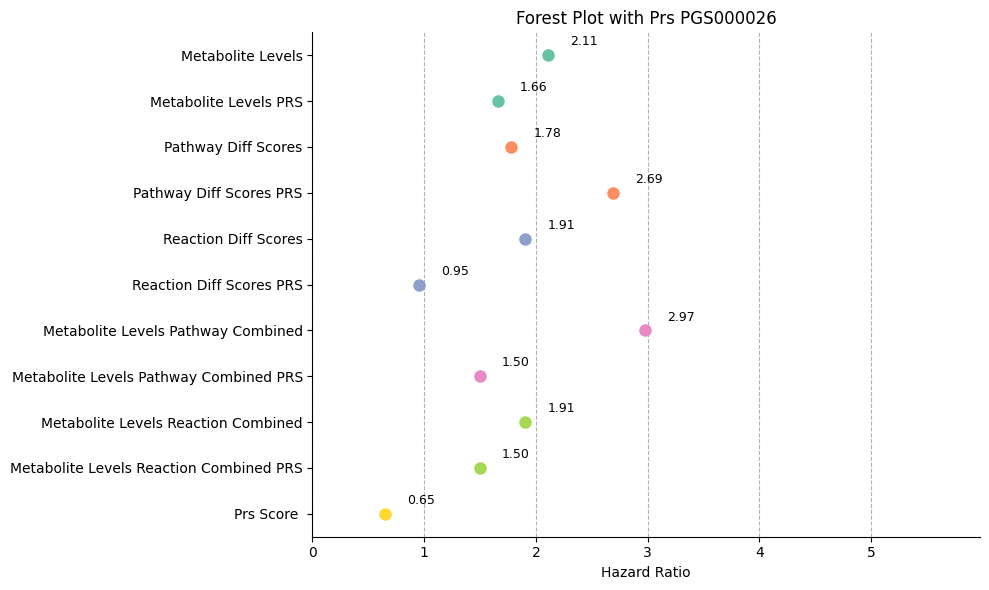

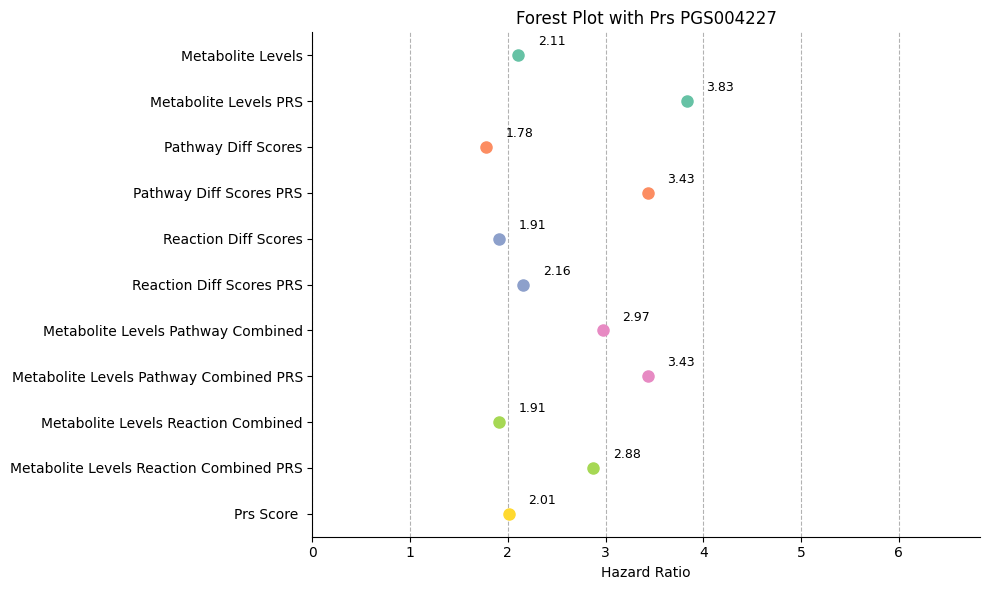

CWD: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD
Log(HR) (coef): 0.9568988523014174
Hazard Ratio (exp(coef)): 2.6036097624386474
P-value: 1.1252257555370838e-05
Log(HR) (coef): 0.8420189531255823
Hazard Ratio (exp(coef)): 2.3210483372623782
P-value: 0.00015369164397406205
Log(HR) (coef): 0.7694314900290189
Hazard Ratio (exp(coef)): 2.1585387540906185
P-value: 0.00048394783487012467
Log(HR) (coef): 0.594571449666231
Hazard Ratio (exp(coef)): 1.8122541364062317
P-value: 0.010746031204669012
Log(HR) (coef): 0.9861502348579926
Hazard Ratio (exp(coef)): 2.680893769099462
P-value: 4.41958690387124e-06
Log(HR) (coef): 1.0762844037672328
Hazard Ratio (exp(coef)): 2.9337586122826016
P-value: 1.4635889400400746e-06
Log(HR) (coef): 1.1782861938662619
Hazard Ratio (exp(coef)): 3.248801612952639
P-value: 5

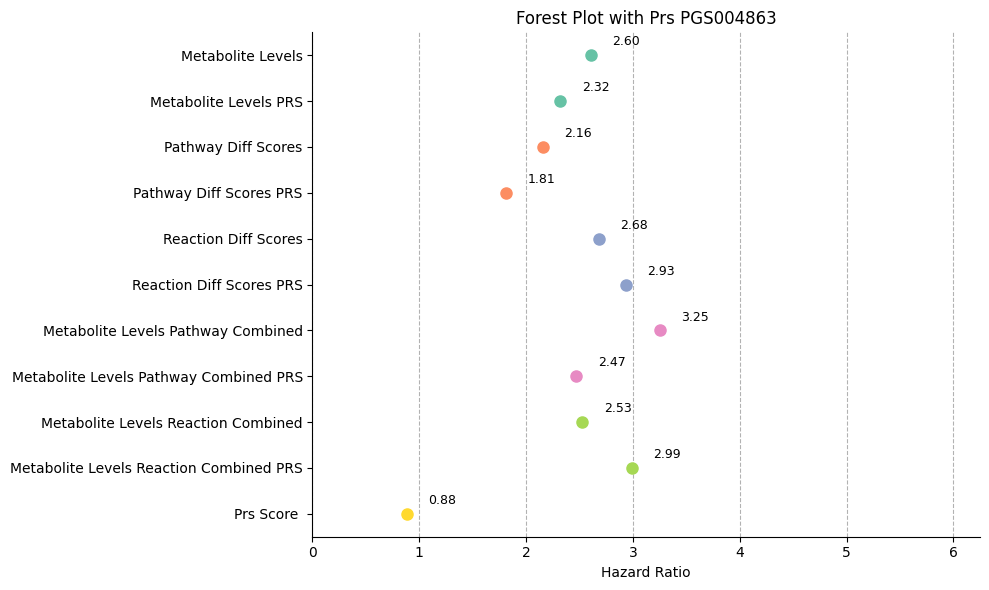

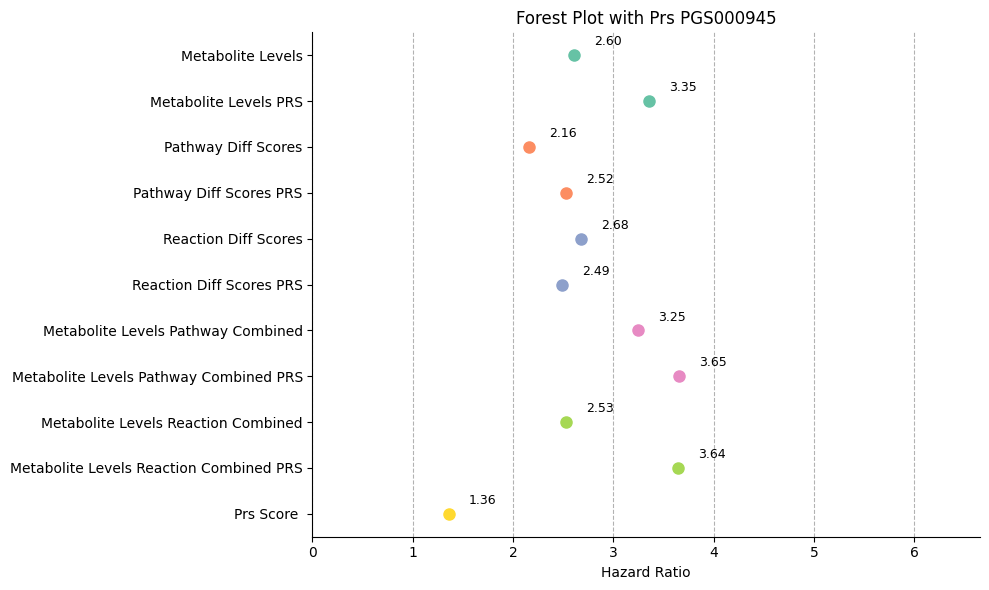

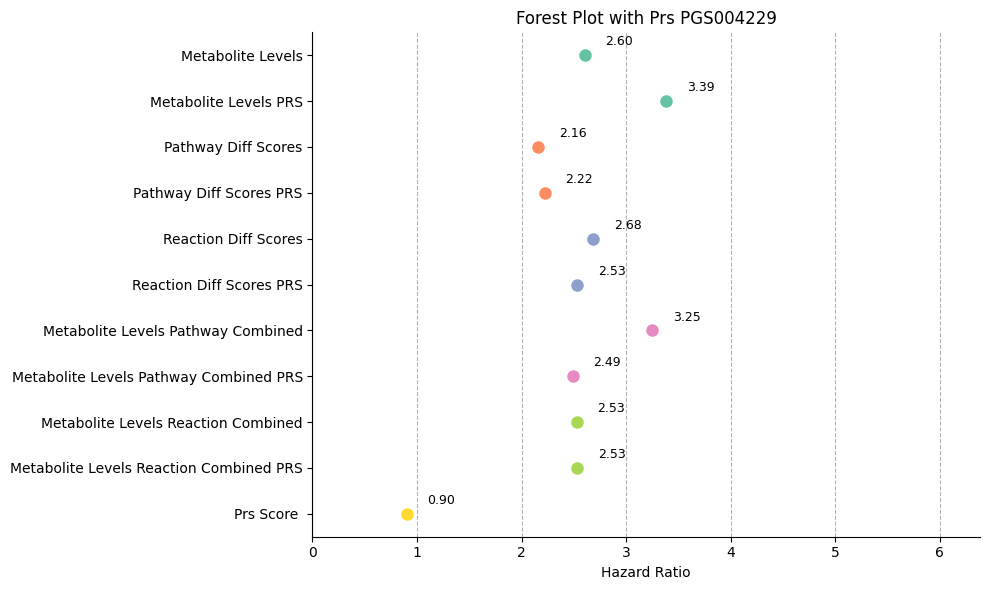

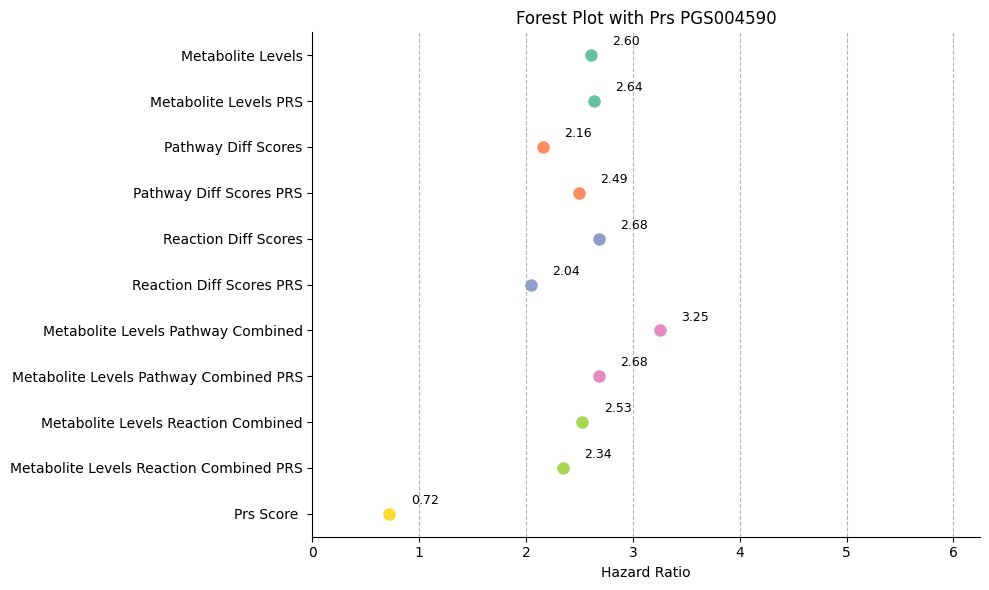

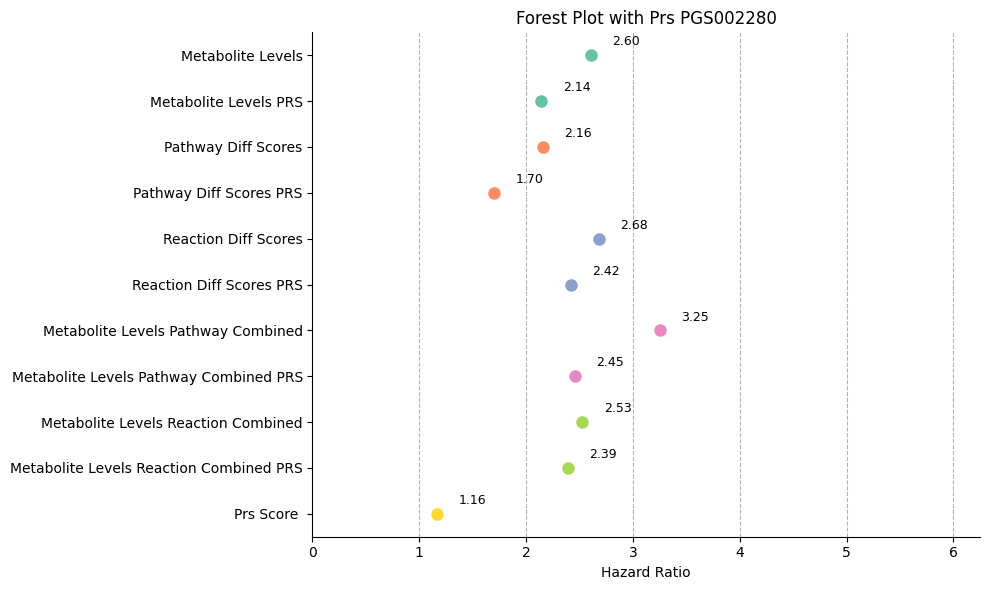

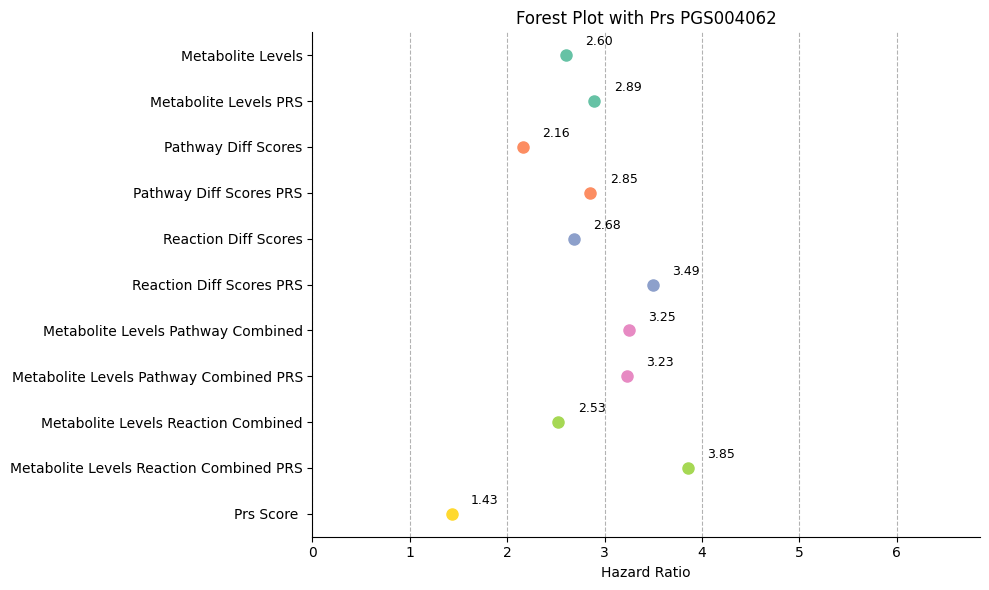

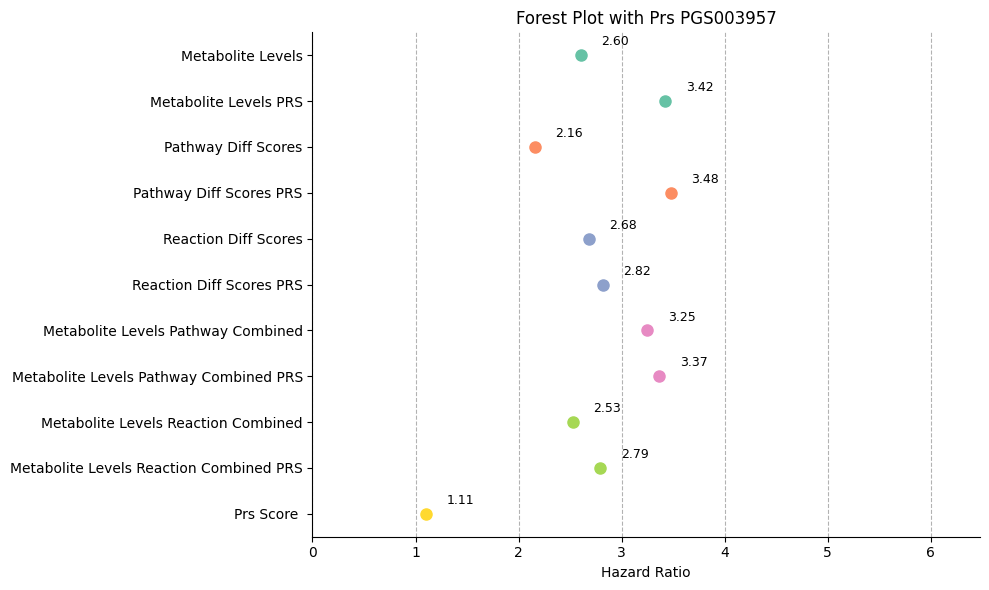

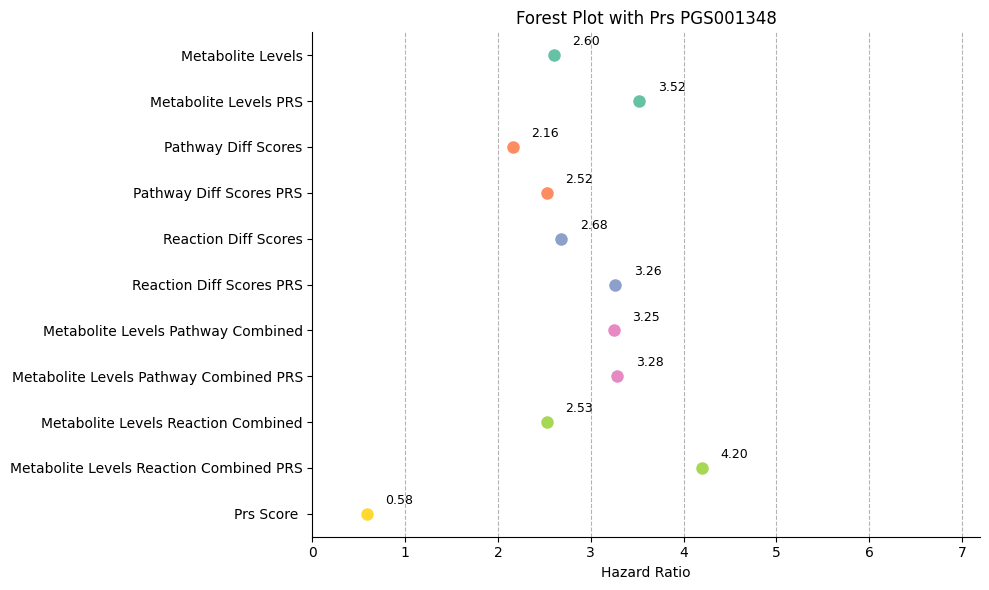

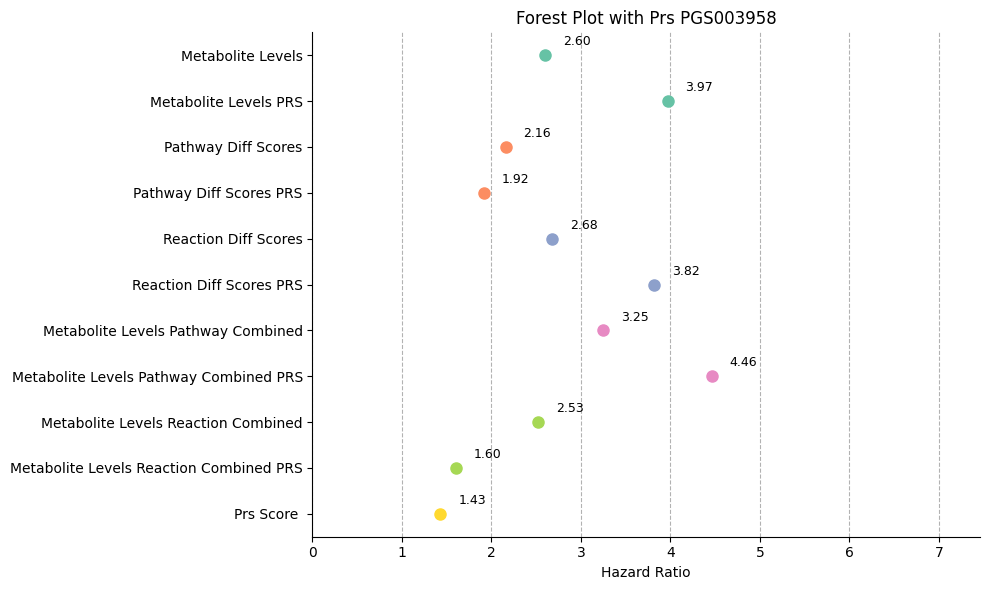

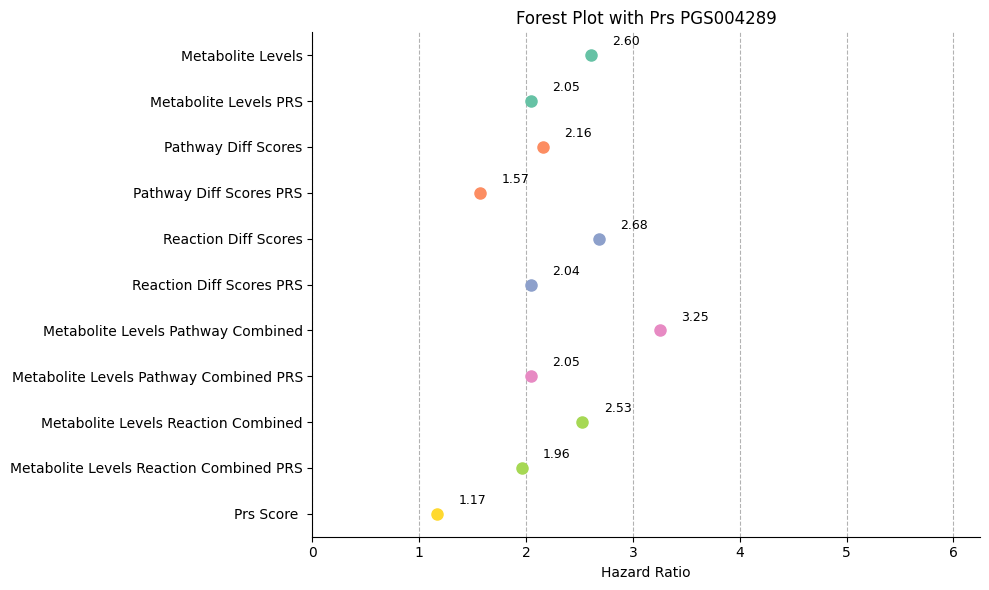

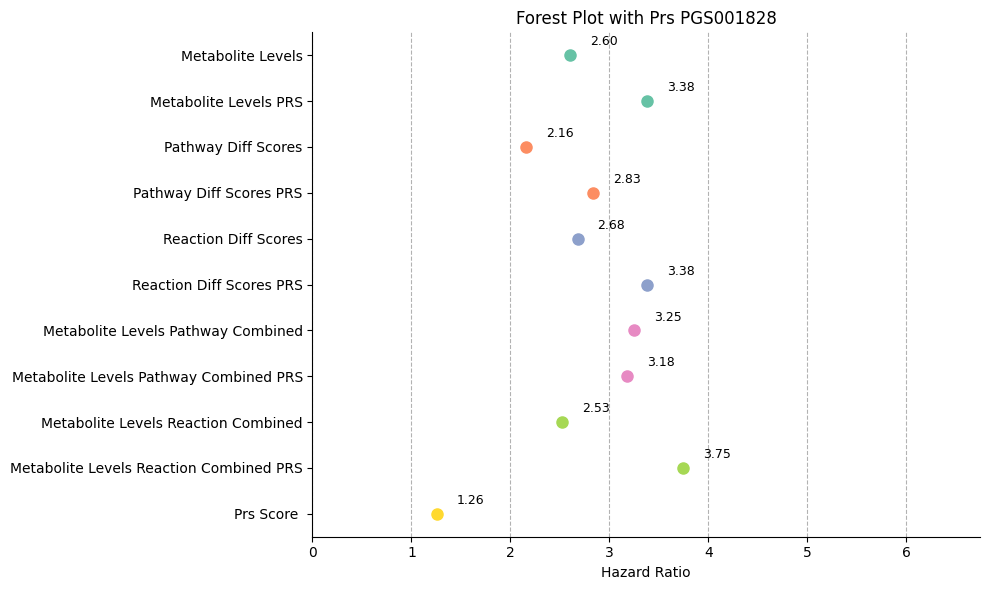

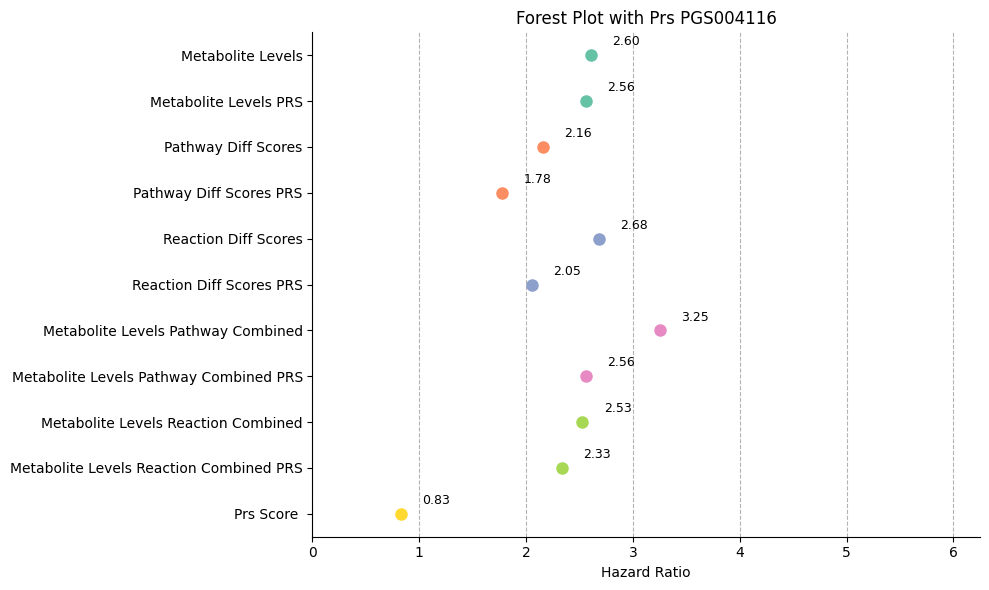

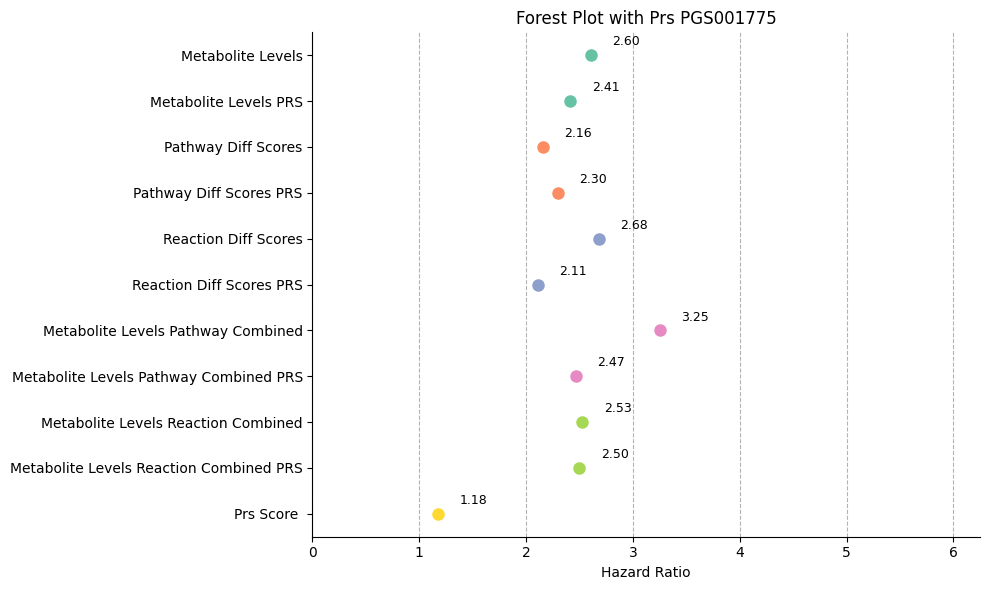

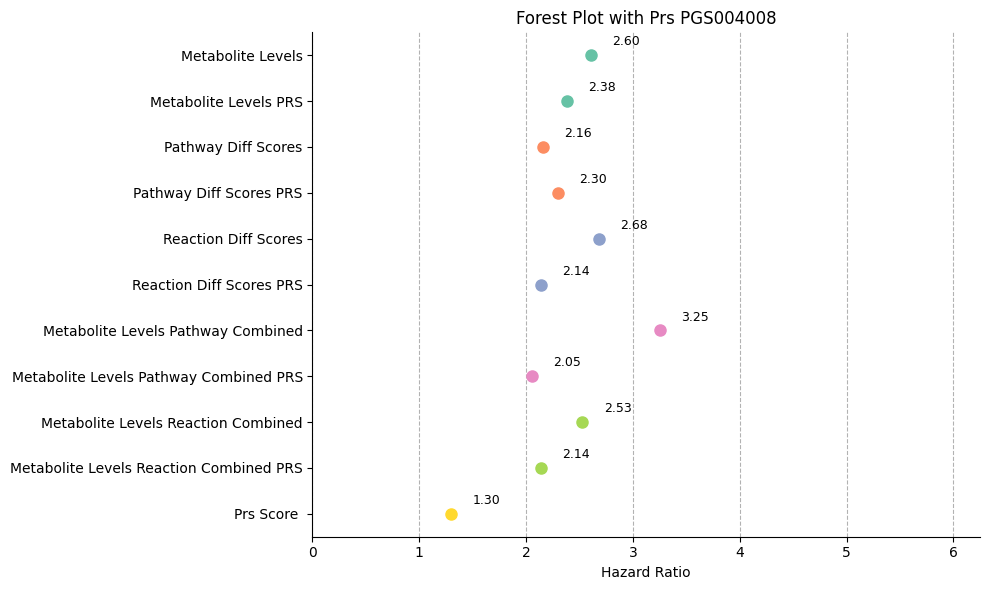

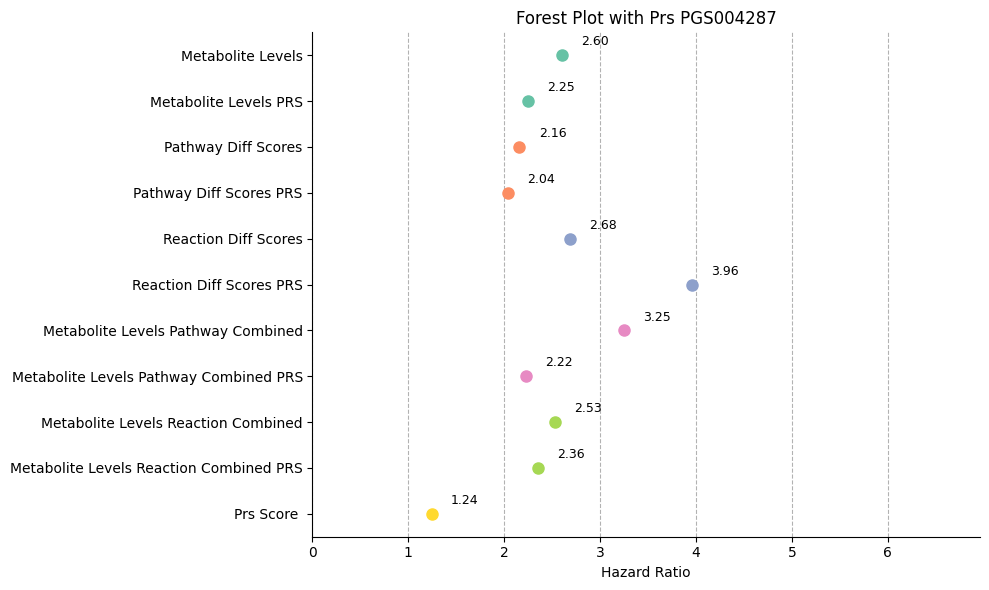

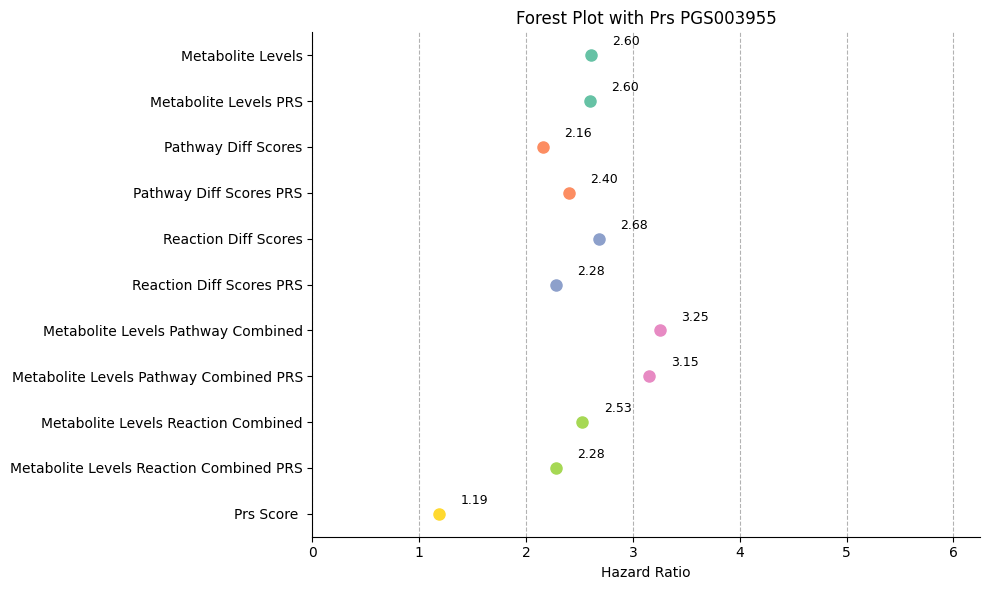

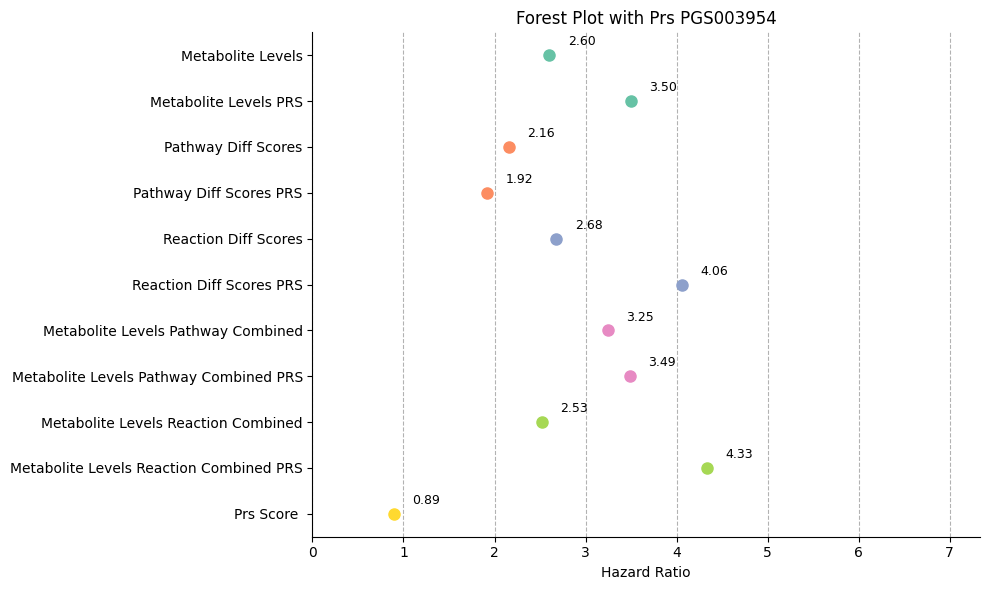

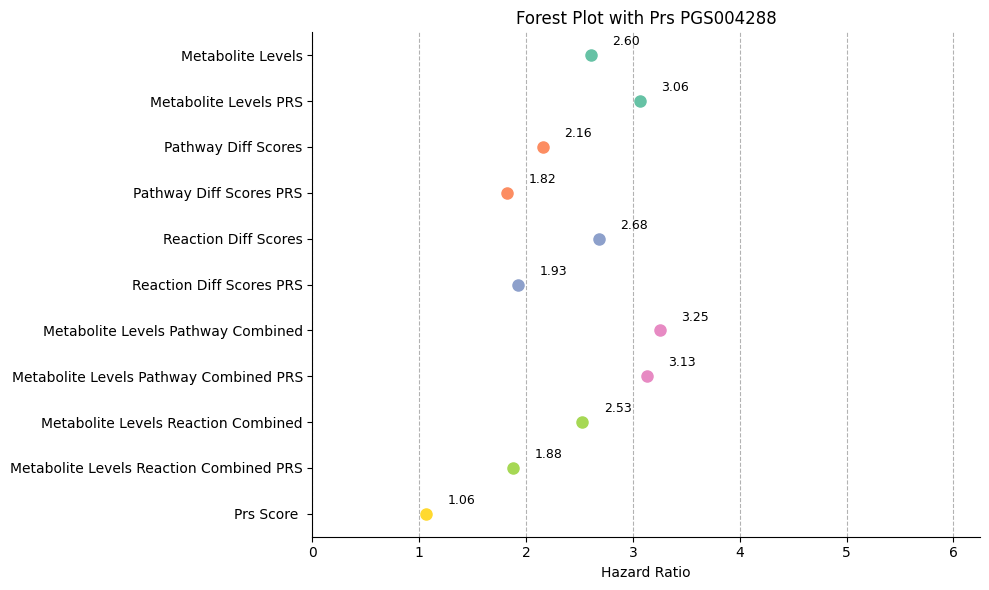

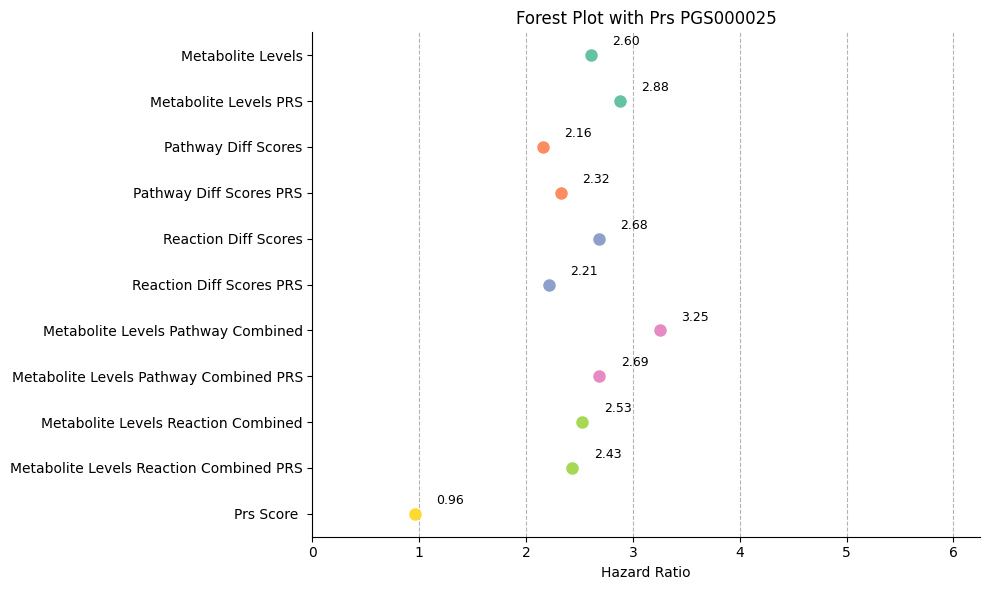

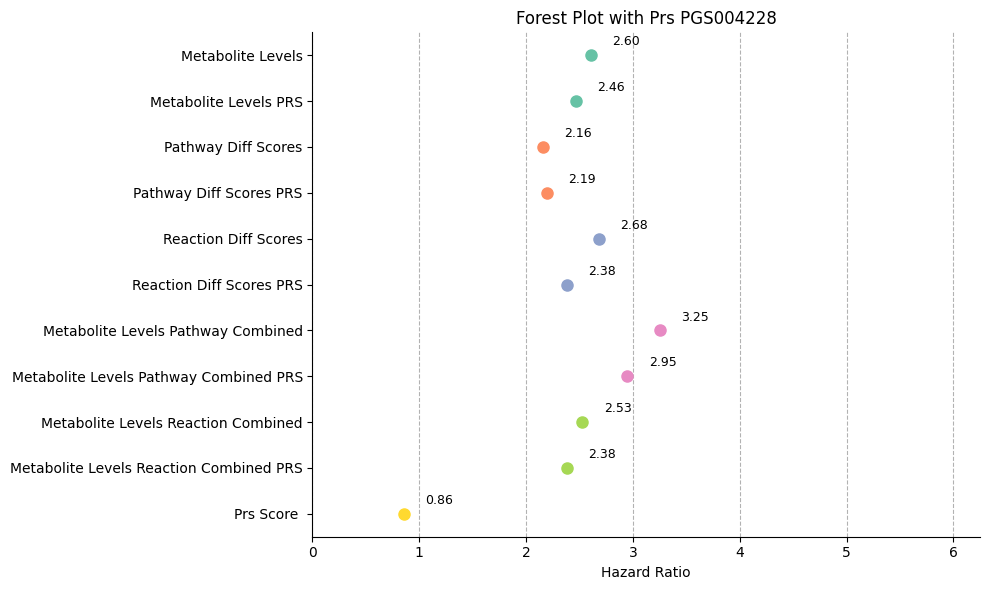

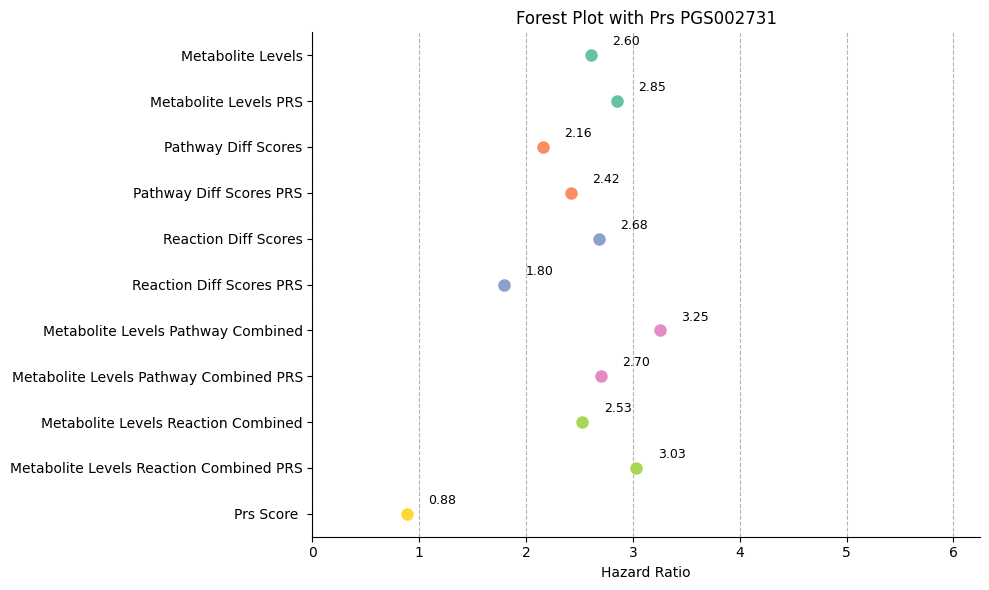

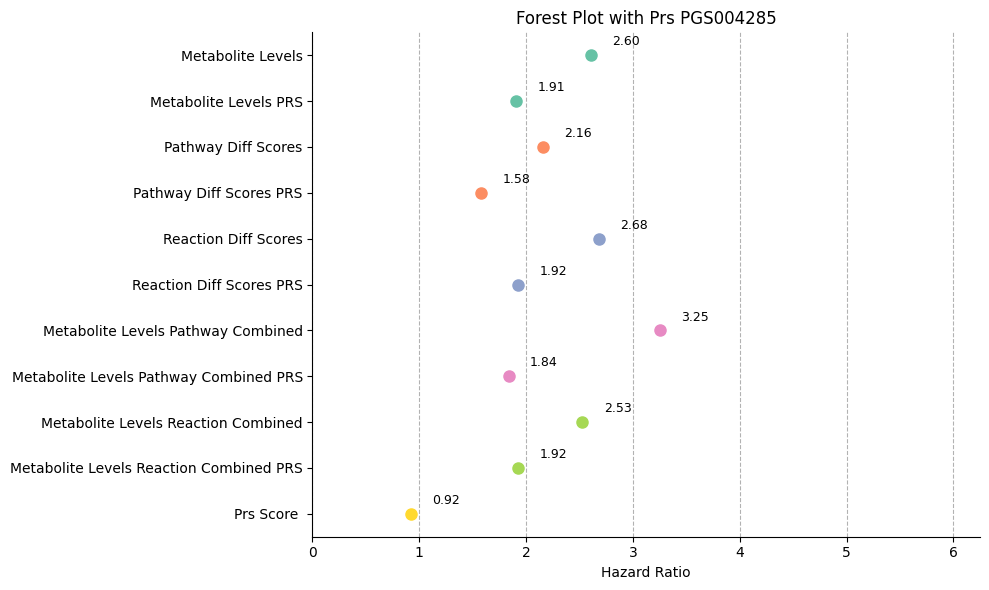

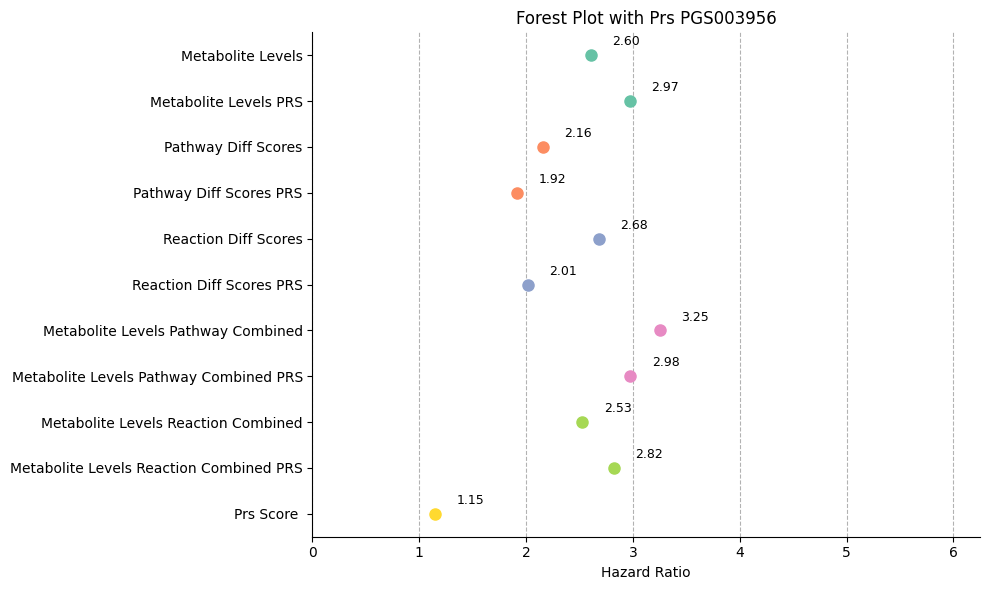

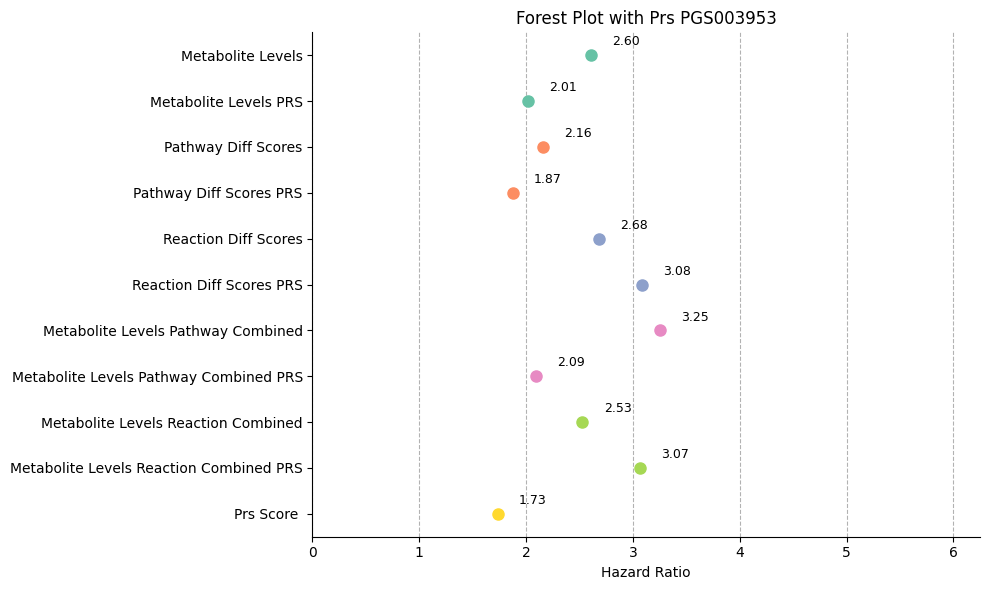

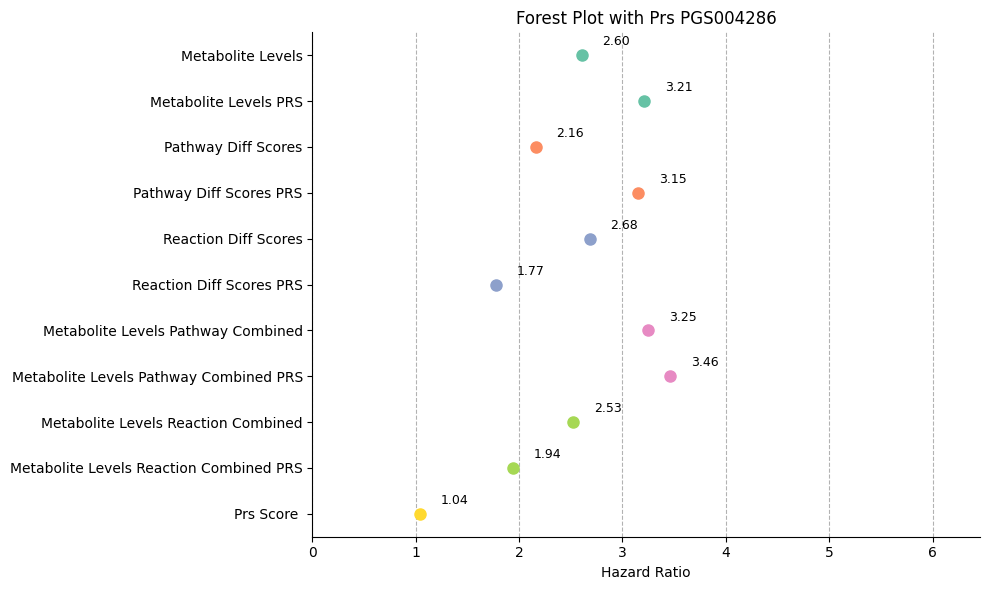

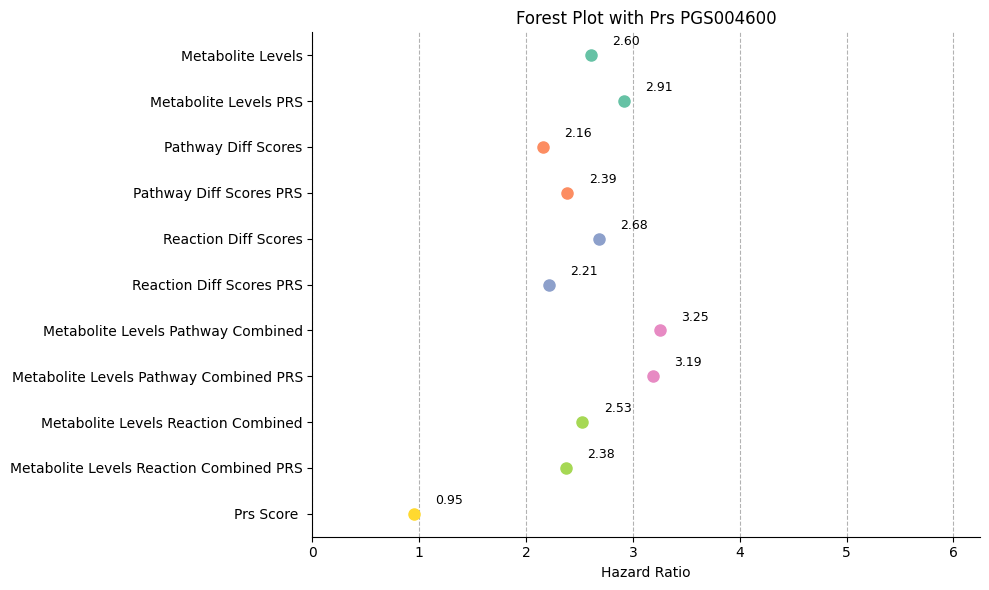

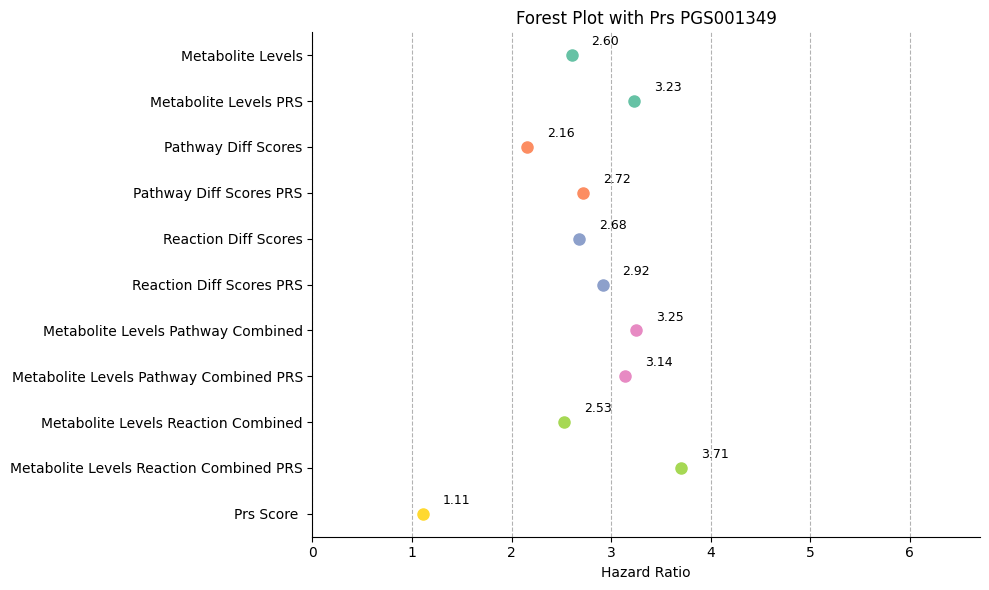

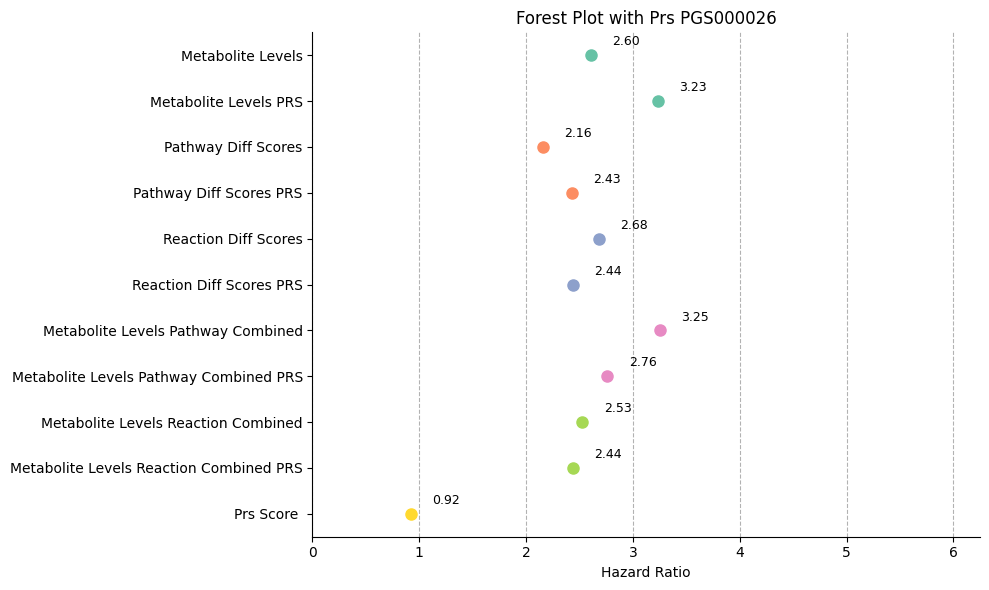

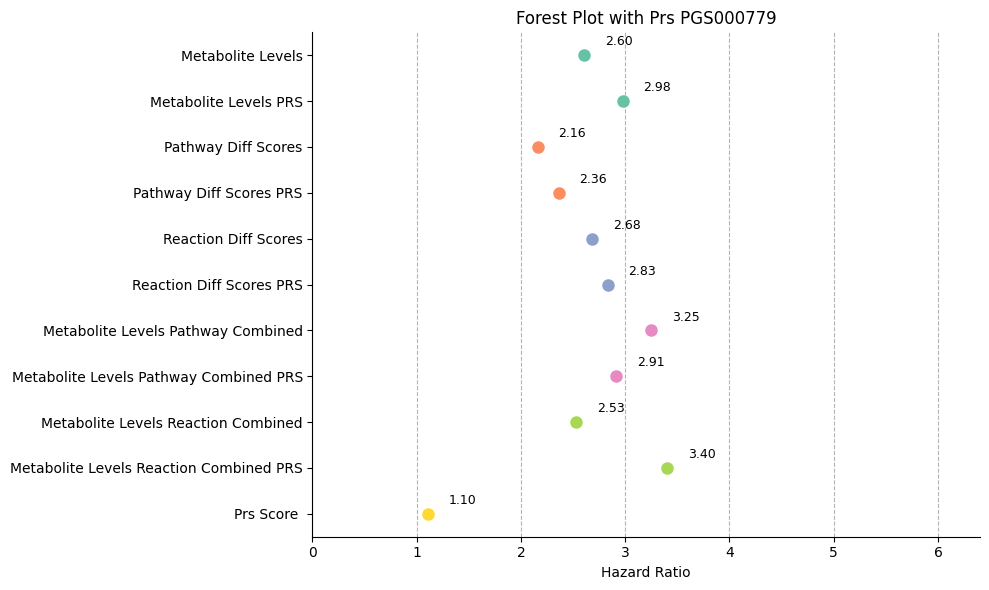

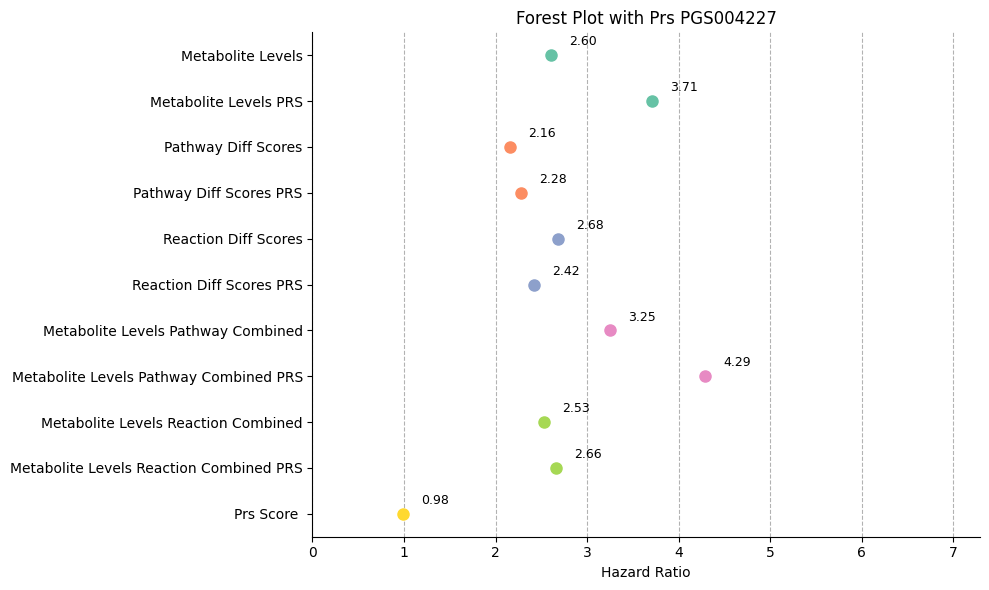

In [2]:
Cohorts = [
    "MayoRNASeq-PSP",
    "DIABETES", "MayoRNASeq-AD","ROSMAP-AD"]

for cohort in Cohorts:
    pipeline = HazardRatioCohortPipeline(cohort)
    pipeline.configure()
    pipeline.run()